In [1]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 12 threads 😎


In [2]:
import Pkg; Pkg.add("Revise")

    Updating registry at `C:\Users\u256063\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\proves\Pushing\Clean\nopushing\Project.toml`
    Manifest No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\proves\Pushing\Clean\nopushing\Manifest.toml`


In [3]:
import Pkg

# Pkg.activate("C:/Users/julia/OneDrive/Escritorio/phd/Bacteria_ABM/ABM_CBM/")
Pkg.activate("./../../../../")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

# ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false

# using CUDA
# CUDA.set_runtime_version!(v"12.2")

using Revise
using CellBasedModels
using Distributions
using CairoMakie
using JSON
using JLD2

import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()

  Activating project at `c:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM`
     Project No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Project.toml`
    Manifest No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Manifest.toml`


In [4]:
# using GeometryBasics, Makie

view_dir(az, el) = Vec3f(cos(az)*cos(el), sin(az)*cos(el), sin(el))

function painter_perm(ax::Axis3, x, y, z)
    az = ax.azimuth[]; el = ax.elevation[]
    v  = view_dir(az, el)
    depths = x .* v[1] .+ y .* v[2] .+ z .* v[3]
    sortperm(depths; rev=false)  # far → near (lejos → cerca)
end

function plotAgents3D_auto!(ax, x, y, z, d, l, theta, phi, p; colormap=:inferno, colorrange=(0,1), kwargs...)
    perm = painter_perm(ax, x, y, z)
    for i in perm
        xi, yi, zi = x[i], y[i], z[i]
        di, li = d[i], l[i]
        thetai, phii, pi = theta[i], phi[i], p[i]

        ux = cos(thetai) * cos(phii)
        uy = sin(thetai) * cos(phii)
        uz = sin(phii)

        x_plus  = xi + 0.5li*ux; y_plus  = yi + 0.5li*uy; z_plus  = zi + 0.5li*uz
        x_minus = xi - 0.5li*ux; y_minus = yi - 0.5li*uy; z_minus = zi - 0.5li*uz
        r = Float32(di/2)

        mesh!(ax, Sphere(Point3f(x_plus,  y_plus,  z_plus),  r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)
        mesh!(ax, Sphere(Point3f(x_minus, y_minus, z_minus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)
        mesh!(ax, Cylinder(Point3f(x_minus, y_minus, z_minus), Point3f(x_plus, y_plus, z_plus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)

    end
    return
end




plotAgents3D_auto! (generic function with 1 method)

# Terracing


In [5]:
rod3D_grow = ABM(3,
    agent = Dict(
            :theta=>Float64,
            :phi =>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :fz=>Float64,
            :Wtheta=>Float64,
            :Wphi=>Float64,
            :lTarget => Float64,
            :V => Float64,

        ),    #Local Interaction Parameters

    model = Dict(
            :Ebb =>Float64,
            :eta =>Float64,
            :eps =>Float64,
            :gamma =>Float64,
            :lMax => Float64,
            :σlTarget => Float64,
            :Ebv => Float64,
            :g => Float64,
            :h0 => Float64,
            :Ebp => Float64,
            :alpha_HP =>Float64,
            :K_HP =>Float64,
            :D_HP =>Float64,
            :Kc =>Float64,
            :beta_c =>Float64,
            :D_c =>Float64,
            :c0 =>Float64,
            :gamma_c => Float64,
            :eps_cs =>Float64,
            :gamma_cs =>Float64,
            :D_PGA =>Float64,
            :alpha_PGA =>Float64,
            :KpqC =>Float64,
            :delta_PGA =>Float64,
            :alpha_PhrC =>Float64,
            :alpha_PhrF =>Float64,
            :D_PhrC =>Float64,
            :D_PhrF =>Float64,
            :delta_PhrC =>Float64,
            :delta_PhrF =>Float64,
            :npqC => Int,
            :alpha_V => Float64,
            :delta_V => Float64,
            :beta_V => Float64,
            :KVc => Float64,
            :nV => Int,
            :npc => Int,
            :growth=>Float64,
            :Kpc => Float64,
            :v => Float64,
            :KpqF => Float64,
            :npqF =>Int,



        ),        #Global parameters

    medium = Dict(
            :HPad => Float64,
            :PPad => Float64,
            :c => Float64,
            :PGA => Float64,
            :Hx => Float64,
            :Hy => Float64,
            :PhrF => Float64,
        ),

    agentODE = quote

        fx = 0
        fy = 0
        fz = 0
        Wtheta = 0
        Wphi = 0 

        
        hPad = HPad

        hbac = exp(2*(hPad-z-d/2))
        if hPad>z+d/2
            cbac=c*exp(-gamma_c*(hPad-z-d/2))
            
        else
            cbac=c
        end
        
        dt(l) = l*growth*cbac/(Kc+cbac)
        dt(V)= alpha_V - delta_V*V + beta_V*(hbac)^nV/((KVc)^nV+(hbac)^nV)

        
        

        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.repulsiveForces_rods3d_asym(x,y,z,d,l,theta, phi,
                                    x[i2],y[i2],z[i2],d[i2],l[i2],theta[i2], phi[i2], eta, Ebb, 5)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            fz += Fijz
            Wtheta += Wijtheta
            Wphi += Wijphi

   
            
        end

        

        Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.substrateAttraction_rods_yukawa3d(x,y,z,d,l,theta,phi, 
            eta, eps_cs,gamma_cs)

                    #Append the repulsive forces
        fx += Fijx
        fy += Fijy
        fz += Fijz
        Wtheta += Wijtheta
        Wphi += Wijphi   
        
        Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.substrateRepulsion_rods3d(x,y,z,d,l,theta,phi, 
            eta, Ebv)

        #Append the repulsive forces
        fx += Fijx
        fy += Fijy
        fz += Fijz
        Wtheta += Wijtheta
        Wphi += Wijphi   


        fy += -v*Hy/(eta*(l+d))
        fx += -v*Hx/(eta*(l+d))

        ############################
        # Pad interaction 
        #########################


        Fijx = 0.0; Fijy = 0.0; Fijz = 0.0; Wijtheta=0.0; Wijphi=0.0


         # orientación del rod (tu convención)
        ux =  cos(theta)*cos(phi)
        uy =  sin(theta)*cos(phi)
        uz =  sin(phi)

        # grid spacing
        hx = (simBox[1,2] - simBox[1,1]) / NMedium[1]
        hy = (simBox[2,2] - simBox[2,1]) / NMedium[2]
        Δs_eff = 0.5*min(hx, hy)  # para no saltar celdas


        # recorrer s en [-l/2, l/2]
        K = max(2, ceil(Int, l / Δs_eff))  # aseguras al menos 2
        Δs = l/(K-1)

        for s in LinRange(-l/2, l/2, K)
            # punto en el rod
            xp = x + s*ux
            yp = y + s*uy
            zp = z + s*uz

            # celda del pad
            idx = Int(floor(Int, xp/(simBox[1,2]-simBox[1,1])*NMedium[1]) + NMedium[1]/2)
            if mod(xp, (simBox[1,2]-simBox[1,1])/NMedium[1])>0
                idx += 1
            end
            idy = Int(floor(Int, yp/(simBox[2,2]-simBox[2,1])*NMedium[2])+ NMedium[2]/2)
            if mod(yp, (simBox[2,2]-simBox[2,1])/NMedium[2])>0
                idy += 1
            end
            
            # h local del pad (tu altura / “a” local)
            hPad = com.HPad[idx, idy, 1]

            if hPad<zp+d/2
                # fuerza en ese punto (tu función)
                Fx, Fy, Fz, Wθ, Wφ = CBMModels.padRepulsion_rods_point_3d(
                    x, y, z,  # CM bacteria
                    xp, yp, zp,  # punto sobre el rod
                    d, l, theta, phi,
                    eta, Ebp, hPad
                )

                # acumula bacteria
                Fijx += Fx; Fijy += Fy; Fijz += Fz
                Wijtheta += Wθ; Wijphi += Wφ
                com.PPad[idx, idy, 1] += -Fz*eta*(l+d)* Δs
            end

        end

        
        fx += Fijx* Δs
        fy += Fijy* Δs
        fz += Fijz* Δs
        Wtheta += Wijtheta* Δs
        Wphi += Wijphi* Δs


        ww1 = CBMDistributions.uniform(-1,1)*10^(-3)
        ww2 = CBMDistributions.uniform(-1,1)*10^(-3)
        ww3 = CBMDistributions.uniform(-1,1)*10^(-3)

        #Equations
        dt(x) =  fx +ww1
        dt(y) =  fy +ww2
        dt(z) =  fz 
        dt(theta) =  Wtheta + ww3
        dt(phi) = Wphi
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
           

            # Dirección 3D de la varilla (unitaria)
            ux = cos(theta)*cos(phi)
            uy = sin(theta)*cos(phi)
            uz = sin(phi)

            # === Hija A (delantera, +u) ===
            @addAgent(
                x = x + (l+d)/4 * ux,
                y = y + (l+d)/4 * uy,
                z = z + (l+d)/4 * uz,
                l = (l-d)/2,
                # Wtheta = ww1,
                # Wphi= ww2,
                lTarget = CBMDistributions.uniform(lMax-σlTarget, lMax+σlTarget),
            )

            # === Hija B (trasera, −u) ===
            @addAgent(
                x = x - (l+d)/4 * ux,
                y = y - (l+d)/4 * uy,
                z = z - (l+d)/4 * uz,
                l = (l-d)/2,
                # Wtheta = ww1,
                # Wphi= ww2,
                lTarget = CBMDistributions.uniform(lMax-σlTarget, lMax+σlTarget),
            )

            # Elimina célula madre
            @removeAgent()
        end


        
        hPad = HPad
        hbac = c*exp(4*(hPad-z-d/2))
        if hPad >z+d/2
            cbac =c*exp(-gamma_c*(hPad-z-d/2))
        else
            cbac = c
        end
        c += (-l*beta_c*cbac/(Kc+cbac))*dt


        PhrF += (alpha_PhrF)*dt
        PGA += (alpha_PGA*PhrF^npqF/(PhrF^npqF+KpqF^npqF))*dt
        
    end,

    mediumODE=quote 

            
        if @mediumBorder(1,-1) 
            HPad = h0
            c = c[2,i2_]
            PhrF= PhrF[2,i2_]
            PGA=0
        elseif @mediumBorder(1, 1)
            HPad = h0
            c = c[end-1,i2_]
            PhrF= PhrF[end-1,i2_]
            PGA=0

        elseif @mediumBorder(2,-1)
            HPad = h0
            c = c[i1_,2]
            PhrF= PhrF[i1_,2]
            PGA=0

        elseif @mediumBorder(2, 1)
            HPad = h0
            c = c[i1_,end-1]
            PhrF= PhrF[i1_,end-1]
            PGA=0

        else
            dt(HPad) = alpha_HP*PPad - K_HP*(HPad-h0) + D_HP*(@∂2(1,HPad)+@∂2(2,HPad))
            dt(c) =D_c*(@∂2(1,c)+@∂2(2,c))
            dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA 
            dt(PhrF) = D_PhrF*(@∂2(1,PhrF)+@∂2(2,PhrF)) - delta_PhrF*PhrF

            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
            
        end
    end,
    # neighborsAlg=CBMNeighbors.VerletDisplacement(skin=4.0, nMaxNeighbors=500),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10),
    mediumAlg=DifferentialEquations.Euler(),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


In [6]:
com = Community(rod3D_grow,
            N=2,
            dt=0.0001,
            simBox = [-100 100;-100 100.; -100 100],
            NMedium=[200,200,1],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um

t_reescale = 0.5 #h

com.Ebb=1* 1.E6 *m/(t^2*d)*t_reescale^2 #Pa 
com.eta = 200 *m/(t^2*d)*t_reescale #Pa h
com.eps = 1.E3 *m/(t^2*d)*t_reescale^2 #Pa um^4
com.eps = 0 #Pa um^4
com.gamma=3

com.Ebv = com.Ebb *10 
com.Ebp =  com.Ebb*0.001

com.eps_cs = 5*1.E3 *m/(t^2*d)*t_reescale^2 #Pa um^4
com.gamma_cs=1

com.growth = 2 *t_reescale
com.lMax = 5.     
com.σlTarget = 2

com.d = 1.        
com.l[1] = 4.99      
com.l[2] = 2.5      
com.lTarget = 5.  
com.theta[1]=-pi/4
com.theta[2]=+pi/4
com.x=(com.l+ com.d) ./2 .* cos.(com.theta)
com.y=0
# com.z=com.d/2
# com.phi=0
# com.theta=0
# com.x=0
# com.y=0
com.z=com.d/2
com.phi=0


com.h0=0
com.alpha_HP=300*10^(-6) /t_reescale
com.K_HP=100*t_reescale
com.D_HP=500*t_reescale
com.PPad=0
com.HPad=1


com.PGA=0
# com.alpha_PGA = 10
com.alpha_PGA = 50*t_reescale*0
com.delta_PGA = 1*t_reescale
com.D_PGA = 5*t_reescale
com.npc = 10
com.v = 2.5*10^9*t_reescale^2
com.Kpc=0.01

com.KpqC=0.2
com.npqC=4

com.KpqF=0.1
com.npqF=10

com.V=1
com.alpha_V=10
com.delta_V=10
com.beta_V=20
com.KVc=4
com.nV=10


com.D_c = 1000*t_reescale
com.c0 = 1 #Medium concentration
com.c = com.c0 
com.Kc = 1 #Half saturation constant for the medium
com.beta_c = 4*t_reescale #Growth rate of the cells in the medium
com.gamma_c = 5 #Decay with height constant





com.PhrF=0
com.alpha_PhrF = 1*t_reescale
com.delta_PhrF = 0.1*t_reescale
com.D_PhrF = 1500*t_reescale




750.0

In [7]:
# com = Community(rod3D_grow,
#             N=1,
#             dt=0.0001,
#             simBox = [-100 100;-100 100.; -100 100],
#             NMedium=[200,200,1],
#             );


# #Natural units scales
# m = 1.E3 #g
# t = 1/(60*60) # h
# d = 1.E6 #um

# t_reescale = 0.5 #h

# com.Ebb=1* 1.E6 *m/(t^2*d)*t_reescale^2 #Pa 
# com.eta = 200 *m/(t^2*d)*t_reescale #Pa h
# com.eps = 1.E3 *m/(t^2*d)*t_reescale^2 #Pa um^4
# com.eps = 0 #Pa um^4
# com.gamma=3

# com.Ebv = com.Ebb *10 
# com.Ebp =  com.Ebb*0.001

# com.eps_cs = 5*1.E3 *m/(t^2*d)*t_reescale^2 #Pa um^4
# com.gamma_cs=1

# com.growth = 2 *t_reescale
# com.lMax = 5.     
# com.σlTarget = 2

# com.d = 1.        
# com.l[1] = 4.99      
# # com.l[2] = 2.5      
# com.lTarget = 5.  
# com.theta[1]=pi/2
# # com.theta[2]=0
# com.x=(com.l+ com.d) ./2 .* cos.(com.theta)
# com.y=0
# # com.z=com.d/2
# # com.phi=0
# # com.theta=0
# # com.x=0
# # com.y=0
# com.z=com.d/2
# com.phi=0


# com.h0=0
# com.alpha_HP=300*10^(-6) /t_reescale
# com.K_HP=100*t_reescale
# com.D_HP=500*t_reescale
# com.PPad=0
# com.HPad=1


# com.PGA=0
# # com.alpha_PGA = 10
# com.alpha_PGA = 50*t_reescale
# com.delta_PGA = 1*t_reescale
# com.D_PGA = 5*t_reescale
# com.npc = 10
# com.v = 2.5*10^9*t_reescale^2
# com.Kpc=0.01

# com.KpqC=0.2
# com.npqC=4

# com.KpqF=0.1
# com.npqF=10

# com.V=1
# com.alpha_V=10
# com.delta_V=10
# com.beta_V=20
# com.KVc=4
# com.nV=10


# com.D_c = 1000*t_reescale
# com.c0 = 1 #Medium concentration
# com.c = com.c0 
# com.Kc = 1 #Half saturation constant for the medium
# com.beta_c = 4*t_reescale #Growth rate of the cells in the medium
# com.gamma_c = 5 #Decay with height constant





# com.PhrF=0
# com.alpha_PhrF = 1*t_reescale
# com.delta_PhrF = 0.1*t_reescale
# com.D_PhrF = 1500*t_reescale




In [8]:

function save_step!(file, parameters, step)
    grp = JLD2.Group(file, "step_$step")
    for (k,v) in parameters
        grp[string(k)] = v
    end
end

save_step! (generic function with 1 method)

In [9]:
t_reescale

0.5

In [10]:
using JLD2

steps = Int(round(10/t_reescale/com.dt))
saveEach = Int(round(1/t_reescale/com.dt)) ÷ 10

prev_steps = Int(round(0/t_reescale/com.dt))


jldopen("simulation.jld2","w") do file

    N = com.N * 4 
    loadToPlatform!(com, preallocateAgents=N)

    step = prev_steps

    while (step < steps+1) && (com.N < 3000)

        step!(com)

        if step % saveEach == 0

            bringFromPlatform!(com)

            if N - com.N[1] <= 0
                println("Step ",step," N: ",com.N[1]," preallocateAgents: ",N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break

            elseif N - com.N[1] < 4*com.N[1]
                N = 15 * com.N[1]
            end

            println("Step ",step," N: ",com.N[1])

            save_step!(file, com.parameters, step)

            loadToPlatform!(com, preallocateAgents=N)
        end

        step += 1
        com.PPad = 0
    end

    bringFromPlatform!(com)

end

Step 0 N: 2
Step 2000 N: 3
Step 4000 N: 3
Step 6000 N: 3
Step 8000 N: 3
Step 10000 N: 3
Step 12000 N: 3
Step 14000 N: 5
Step 16000 N: 5
Step 18000 N: 5
Step 20000 N: 6
Step 22000 N: 6
Step 24000 N: 6
Step 26000 N: 6
Step 28000 N: 6
Step 30000 N: 7
Step 32000 N: 7
Step 34000 N: 7
Step 36000 N: 9
Step 38000 N: 10
Step 40000 N: 10
Step 42000 N: 11
Step 44000 N: 12
Step 46000 N: 14
Step 48000 N: 14
Step 50000 N: 16
Step 52000 N: 17
Step 54000 N: 18
Step 56000 N: 20
Step 58000 N: 22
Step 60000 N: 22
Step 62000 N: 25
Step 64000 N: 25
Step 66000 N: 27
Step 68000 N: 29
Step 70000 N: 30
Step 72000 N: 34
Step 74000 N: 35
Step 76000 N: 37
Step 78000 N: 38
Step 80000 N: 41
Step 82000 N: 43
Step 84000 N: 48
Step 86000 N: 51
Step 88000 N: 56
Step 90000 N: 61
Step 92000 N: 62
Step 94000 N: 69
Step 96000 N: 77
Step 98000 N: 85
Step 100000 N: 97
Step 102000 N: 103
Step 104000 N: 108
Step 106000 N: 119
Step 108000 N: 127
Step 110000 N: 141
Step 112000 N: 147
Step 114000 N: 153
Step 116000 N: 163
Step 11

In [11]:
file = jldopen("simulation.jld2")

keys(file)
steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))


101-element Vector{Int64}:
      0
   2000
   4000
   6000
   8000
  10000
  12000
  14000
  16000
  18000
      ⋮
 184000
 186000
 188000
 190000
 192000
 194000
 196000
 198000
 200000

In [12]:
file

JLDFile C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\proves\Pushing\Clean\nopushing\simulation.jld2 (read-only)
 ├─📂 step_0
 │  ├─🔢 x
 │  ├─🔢 y
 │  ├─🔢 z
 │  ├─🔢 xₘ
 │  ├─🔢 yₘ
 │  ├─🔢 zₘ
 │  ├─🔢 d
 │  └─ ⋯ (59 more entries)
 └─ ⋯ (100 more entries)

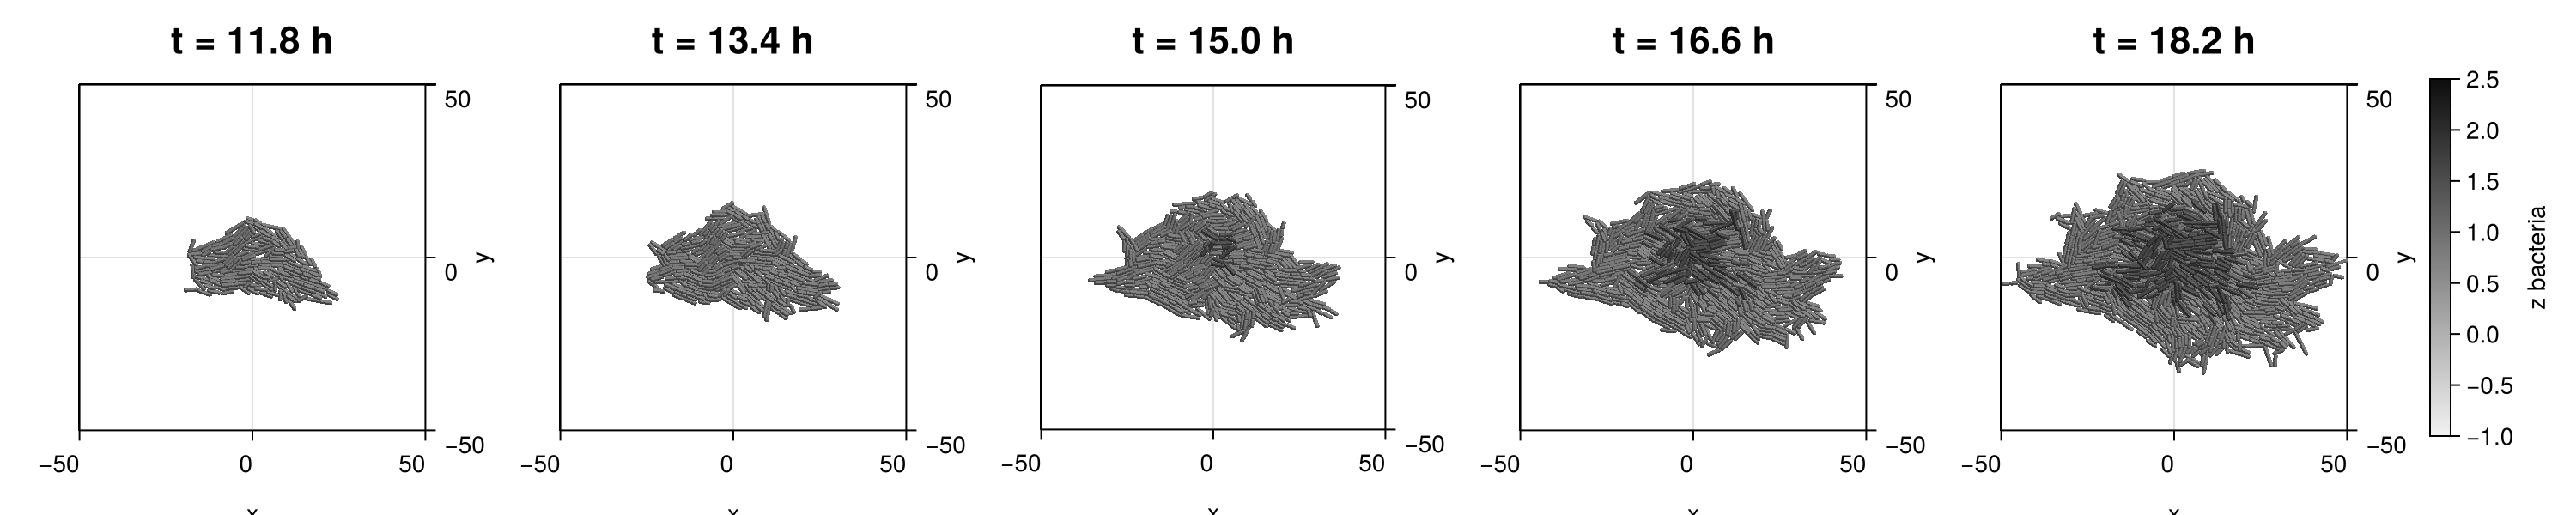

In [13]:
using JLD2

fig = Figure(size = (1500, 300))

file = jldopen("simulation.jld2", "r")

# obtener pasos guardados
steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))

sort!(steps)

# escoger pasos
js = steps[60:10:end]
js=steps[60:8:end-5]

for (i, j) in enumerate(js)

    params = file["step_$j"]

    ax = Axis3(fig[1, i],
        azimuth = 3π/2,
        elevation = π/2,
        zlabelvisible = false,
        zticklabelsvisible = false,
        zgridvisible = false,
        zspinesvisible = false,
        aspect = (1, 1, 0.5),
        title = "t = $(round(j/1e4, digits=2)) h",
        titlesize = 22,
        titlegap = 10
    )

    plotAgents3D_auto!(
        ax,
        params["x"],
        params["y"],
        params["z"],
        params["d"],
        params["l"],
        params["theta"],
        params["phi"],
        params["z"],
        colormap = Reverse(:grays),
        colorrange = (-1, 2.5),
    )

    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
    zlims!(ax, -10, 10)

end

Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:grays),
    colorrange = (-1, 2.5),
    label = "z bacteria"
)

save("NonPushing_z.png", fig; dpi = 900)
display(fig)

close(file)

In [14]:
js=steps[60:8:end-5]

5-element Vector{Int64}:
 118000
 134000
 150000
 166000
 182000

In [15]:
js=steps[50:10:end]


6-element Vector{Int64}:
  98000
 118000
 138000
 158000
 178000
 198000

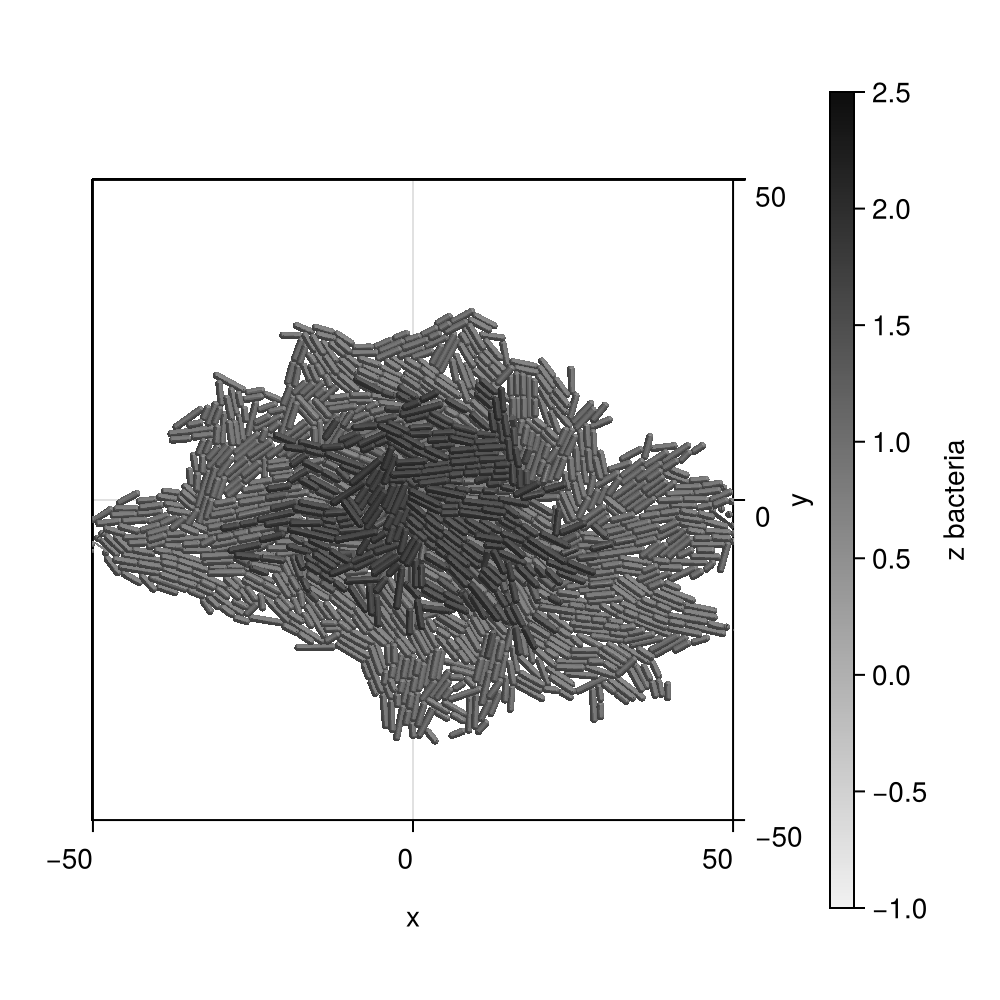

In [16]:
using JLD2

fig = Figure(size=(500,500))

file = jldopen("simulation.jld2","r")

# obtener pasos guardados
steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
last_step = maximum(steps)

params = file["step_$last_step"]

ax = Axis3(fig[1,1],
    azimuth = 3π/2,
    elevation = π/2,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zgridvisible=false,
    zspinesvisible=false,
    aspect=(1,1,0.5)
)

plotAgents3D_auto!(
    ax,
    params["x"],
    params["y"],
    params["z"],
    params["d"],
    params["l"],
    params["theta"],
    params["phi"],
    params["z"],
    colorrange=(-1,2.5),
    colormap=Reverse(:grays)
)

xlims!(-50,50)
ylims!(-50,50)
zlims!(-10,10)

Colorbar(fig[1,2],
    colormap=Reverse(:grays),
    colorrange=(-1,2.5),
    label="z bacteria"
)

display(fig)

close(file)

In [17]:
using Images, ImageMorphology


In [18]:


# ============================
function fill_holes(mask::BitMatrix)
    bg  = .!mask                    # fondo
    lbl = label_components(bg)      # etiquetas de fondo

    ny, nx = size(mask)
    border_labels = Set{Int}()

    # etiquetas de fondo que tocan el borde de la imagen
    union!(border_labels, lbl[1, :])
    union!(border_labels, lbl[end, :])
    union!(border_labels, lbl[:, 1])
    union!(border_labels, lbl[:, end])

    filled = copy(mask)

    @inbounds for i in 1:ny, j in 1:nx
        lab = lbl[i, j]
        if lab != 0 && !(lab in border_labels)
            filled[i, j] = true
        end
    end

    return filled
end

# ===============================
# Suavizado circular
# ===============================

function smooth_circular(x, w)

    n = length(x)
    y = similar(x)

    hw = div(w,2)

    for i in 1:n

        s = 0.0
        c = 0

        for k in -hw:hw
            j = mod1(i+k, n)
            s += x[j]
            c += 1
        end

        y[i] = s/c

    end

    return y

end


# ===============================
# Perímetro + centroide + CV
# ===============================

function colony_perimeter_centroid_cv(frame; px=0.5, bounds=nothing,
                                      cell_diam=2.0, sample_step=0.2,
                                      smooth_window=20)

    # compatible con Dict o JLD2.Group
    getf(frame,k) = try frame[k] catch; frame[Symbol(k)] end

    xs = getf(frame,"x")
    ys = getf(frame,"y")
    ls = getf(frame,"l")
    ts = getf(frame,"theta")
    ps = getf(frame,"phi")

    # ===============================
    # límites
    # ===============================

    if bounds === nothing

        xmin = minimum(xs); xmax = maximum(xs)
        ymin = minimum(ys); ymax = maximum(ys)

        pad = max(3px,3.0)

        xmin -= pad
        xmax += pad
        ymin -= pad
        ymax += pad

    else

        xmin,xmax,ymin,ymax = bounds

    end

    nx = Int(cld(xmax-xmin,px))
    ny = Int(cld(ymax-ymin,px))

    # ===============================
    # rasterización
    # ===============================

    mask = falses(ny,nx)

    Δs = sample_step * px

    for (x0,y0,l,θ,φ) in zip(xs,ys,ls,ts,ps)

        ux = cos(θ)*cos(φ)
        uy = sin(θ)*cos(φ)

        K = max(2,ceil(Int,l/Δs))

        @inbounds for s in LinRange(-l/2,l/2,K)

            xp = x0 + s*ux
            yp = y0 + s*uy

            j = clamp(Int(floor((xp-xmin)/px))+1,1,nx)
            i = clamp(Int(floor((yp-ymin)/px))+1,1,ny)

            mask[i,j] = true

        end

    end

    # ===============================
    # morfología
    # ===============================

    rpx = max(1,Int(round((cell_diam/2)/px)))

    K = trues(2rpx+1,2rpx+1)

    dil  = dilate(mask,K)
    clos = erode(dil,K)

    clos_filled = fill_holes(clos)

    perim = clos_filled .& .!erode(clos_filled,trues(3,3))

    # ===============================
    # centroide
    # ===============================

    Iarea = findall(clos_filled)

    @assert !isempty(Iarea) "Máscara vacía; revisa px/bounds/cell_diam."

    x_area = xmin .+ ((getindex.(Iarea,2).-1).*px)
    y_area = ymin .+ ((getindex.(Iarea,1).-1).*px)

    cx = mean(x_area)
    cy = mean(y_area)

    # ===============================
    # perímetro
    # ===============================

    Iper = findall(perim)

    @assert !isempty(Iper) "Perímetro vacío; revisa px/bounds/cell_diam."

    perim_x = xmin .+ ((getindex.(Iper,2).-1).*px)
    perim_y = ymin .+ ((getindex.(Iper,1).-1).*px)

    θ = atan.(perim_y .- cy, perim_x .- cx)

    ord = sortperm(θ)

    perim_x = perim_x[ord]
    perim_y = perim_y[ord]
    θ = θ[ord]

    # ===============================
    # 🔹 suavizado radial
    # ===============================

    r = hypot.(perim_x .- cx, perim_y .- cy)

    r_s = smooth_circular(r, smooth_window)

    perim_x = cx .+ r_s .* cos.(θ)
    perim_y = cy .+ r_s .* sin.(θ)

    # ===============================
    # CV radial
    # ===============================

    d = hypot.(perim_x .- cx, perim_y .- cy)

    μ = mean(d)
    σ = std(d)

    cv = σ/μ

    # ===============================
    # área y densidad
    # ===============================

    area_px = count(clos_filled)

    area_um2 = area_px * px^2

    N = length(xs)

    density = N / area_um2

    return (perim_x=perim_x,perim_y=perim_y,
            cx=cx,cy=cy,cv=cv,mu=μ,sigma=σ,
            mask=mask,clos=clos,clos_filled=clos_filled,perim=perim,
            bounds=(xmin,xmax,ymin,ymax),px=px,
            area_px=area_px,area_um2=area_um2,
            N=N,density=density)

end

colony_perimeter_centroid_cv (generic function with 1 method)

In [19]:
# using CairoMakie

# parula = cgrad([
#     RGBf(0.2081,0.1663,0.5292),
#     RGBf(0.2116,0.1898,0.5777),
#     RGBf(0.2123,0.2138,0.6270),
#     RGBf(0.2081,0.2386,0.6771),
#     RGBf(0.1959,0.2645,0.7279),
#     RGBf(0.1707,0.2919,0.7792),
#     RGBf(0.1253,0.3242,0.8303),
#     RGBf(0.0591,0.3598,0.8683),
#     RGBf(0.0117,0.3875,0.8820),
#     RGBf(0.0060,0.4086,0.8828),
#     RGBf(0.0165,0.4266,0.8786),
#     RGBf(0.0329,0.4430,0.8720),
#     RGBf(0.0498,0.4586,0.8641),
#     RGBf(0.0629,0.4737,0.8554),
#     RGBf(0.0723,0.4887,0.8467),
#     RGBf(0.0779,0.5040,0.8384),
#     RGBf(0.0793,0.5200,0.8312),
#     RGBf(0.0749,0.5375,0.8263),
#     RGBf(0.0641,0.5570,0.8240),
#     RGBf(0.0488,0.5772,0.8228),
#     RGBf(0.0343,0.5966,0.8199),
#     RGBf(0.0265,0.6137,0.8135),
#     RGBf(0.0239,0.6287,0.8038),
#     RGBf(0.0231,0.6418,0.7913),
#     RGBf(0.0228,0.6535,0.7768),
#     RGBf(0.0267,0.6642,0.7607),
#     RGBf(0.0384,0.6743,0.7436),
#     RGBf(0.0590,0.6838,0.7254),
#     RGBf(0.0843,0.6928,0.7062),
#     RGBf(0.1133,0.7015,0.6859),
#     RGBf(0.1453,0.7098,0.6646),
#     RGBf(0.1801,0.7177,0.6424),
#     RGBf(0.2178,0.7250,0.6193),
#     RGBf(0.2586,0.7317,0.5954),
#     RGBf(0.3022,0.7376,0.5712),
#     RGBf(0.3482,0.7424,0.5473),
#     RGBf(0.3953,0.7459,0.5244),
#     RGBf(0.4420,0.7481,0.5033),
#     RGBf(0.4871,0.7491,0.4840),
#     RGBf(0.5300,0.7491,0.4661),
#     RGBf(0.5709,0.7485,0.4494),
#     RGBf(0.6099,0.7473,0.4337),
#     RGBf(0.6473,0.7456,0.4188),
#     RGBf(0.6834,0.7435,0.4044),
#     RGBf(0.7184,0.7411,0.3905),
#     RGBf(0.7525,0.7384,0.3768),
#     RGBf(0.7858,0.7356,0.3633),
#     # RGBf(0.8185,0.7327,0.3498),
#     # RGBf(0.8507,0.7299,0.3360),
#     # RGBf(0.8824,0.7274,0.3217),
#     # RGBf(0.9139,0.7258,0.3063),
#     # RGBf(0.9450,0.7261,0.2886),
#     # RGBf(0.9739,0.7314,0.2666),
#     # RGBf(0.9938,0.7455,0.2403),
#     # RGBf(0.9990,0.7653,0.2164),
#     # RGBf(0.9955,0.7861,0.1967),
#     # RGBf(0.9880,0.8066,0.1794),
#     # RGBf(0.9789,0.8271,0.1633),
#     # RGBf(0.9697,0.8481,0.1475),
#     # RGBf(0.9626,0.8705,0.1309),
#     # RGBf(0.9589,0.8949,0.1132),
#     # RGBf(0.9598,0.9218,0.0948),
#     # RGBf(0.9661,0.9514,0.0755),
#     # RGBf(0.9763,0.9831,0.0538)
# ])

In [20]:
using CairoMakie

parula = cgrad([
    RGBf(0.6297, 0.7859, 0.2521),
    RGBf(0.6161, 0.7878, 0.2622),
    RGBf(0.6024, 0.7896, 0.2726),
    RGBf(0.5886, 0.7913, 0.2833),
    RGBf(0.5748, 0.7929, 0.2941),
    RGBf(0.5609, 0.7943, 0.3050),
    RGBf(0.5470, 0.7957, 0.3159),
    RGBf(0.5329, 0.7970, 0.3267),
    RGBf(0.5187, 0.7982, 0.3374),
    RGBf(0.5044, 0.7993, 0.3480),
    RGBf(0.4899, 0.8002, 0.3586),
    RGBf(0.4753, 0.8011, 0.3691),
    RGBf(0.4608, 0.8018, 0.3797),
    RGBf(0.4463, 0.8024, 0.3904),
    RGBf(0.4322, 0.8028, 0.4013),
    RGBf(0.4184, 0.8030, 0.4122),
    RGBf(0.4050, 0.8031, 0.4233),
    RGBf(0.3921, 0.8029, 0.4344),
    RGBf(0.3795, 0.8026, 0.4454),
    RGBf(0.3671, 0.8021, 0.4563),
    RGBf(0.3548, 0.8016, 0.4669),
    RGBf(0.3424, 0.8009, 0.4774),
    RGBf(0.3301, 0.8002, 0.4876),
    RGBf(0.3176, 0.7994, 0.4975),
    RGBf(0.3052, 0.7985, 0.5074),
    RGBf(0.2929, 0.7975, 0.5170),
    RGBf(0.2809, 0.7964, 0.5266),
    RGBf(0.2695, 0.7951, 0.5360),
    RGBf(0.2589, 0.7937, 0.5454),
    RGBf(0.2491, 0.7922, 0.5546),
    RGBf(0.2401, 0.7905, 0.5636),
    RGBf(0.2318, 0.7887, 0.5725),
    RGBf(0.2244, 0.7869, 0.5813),
    RGBf(0.2178, 0.7849, 0.5899),
    RGBf(0.2118, 0.7828, 0.5983),
    RGBf(0.2061, 0.7808, 0.6065),
    RGBf(0.2003, 0.7787, 0.6146),
    RGBf(0.1954, 0.7765, 0.6225),
    RGBf(0.1905, 0.7743, 0.6303),
    RGBf(0.1853, 0.7721, 0.6379),
    RGBf(0.1799, 0.7699, 0.6454),
    RGBf(0.1741, 0.7678, 0.6527),
    RGBf(0.1678, 0.7656, 0.6599),
    RGBf(0.1609, 0.7635, 0.6671),
    RGBf(0.1532, 0.7614, 0.6741),
    RGBf(0.1448, 0.7593, 0.6812),
    RGBf(0.1354, 0.7572, 0.6881),
    RGBf(0.1252, 0.7552, 0.6950),
    RGBf(0.1141, 0.7531, 0.7019),
    RGBf(0.1023, 0.7510, 0.7088),
    RGBf(0.0899, 0.7489, 0.7156),
    RGBf(0.0770, 0.7468, 0.7224),
    RGBf(0.0638, 0.7446, 0.7292),
    RGBf(0.0504, 0.7423, 0.7359),
    RGBf(0.0369, 0.7400, 0.7426),
    RGBf(0.0253, 0.7376, 0.7492),
    RGBf(0.0162, 0.7352, 0.7558),
    RGBf(0.0094, 0.7327, 0.7623),
    RGBf(0.0046, 0.7301, 0.7688),
    RGBf(0.0018, 0.7275, 0.7752),
    RGBf(0.0009, 0.7248, 0.7815),
    RGBf(0.0019, 0.7220, 0.7878),
    RGBf(0.0046, 0.7192, 0.7941),
    RGBf(0.0091, 0.7163, 0.8003),
    RGBf(0.0155, 0.7133, 0.8064),
    RGBf(0.0234, 0.7103, 0.8124),
    RGBf(0.0328, 0.7071, 0.8183),
    RGBf(0.0433, 0.7039, 0.8242),
    RGBf(0.0535, 0.7006, 0.8299),
    RGBf(0.0628, 0.6972, 0.8355),
    RGBf(0.0713, 0.6938, 0.8409),
    RGBf(0.0789, 0.6902, 0.8462),
    RGBf(0.0855, 0.6865, 0.8513),
    RGBf(0.0914, 0.6828, 0.8562),
    RGBf(0.0964, 0.6789, 0.8609),
    RGBf(0.1009, 0.6750, 0.8653),
    RGBf(0.1048, 0.6710, 0.8695),
    RGBf(0.1085, 0.6669, 0.8734),
    RGBf(0.1119, 0.6627, 0.8770),
    RGBf(0.1152, 0.6584, 0.8804),
    RGBf(0.1185, 0.6541, 0.8834),
    RGBf(0.1219, 0.6497, 0.8862),
    RGBf(0.1253, 0.6453, 0.8887),
    RGBf(0.1288, 0.6408, 0.8910),
    RGBf(0.1321, 0.6363, 0.8932),
    RGBf(0.1354, 0.6317, 0.8953),
    RGBf(0.1383, 0.6272, 0.8975),
    RGBf(0.1408, 0.6226, 0.8998),
    RGBf(0.1429, 0.6180, 0.9022),
    RGBf(0.1446, 0.6135, 0.9050),
    RGBf(0.1461, 0.6089, 0.9080),
    RGBf(0.1475, 0.6043, 0.9113),
    RGBf(0.1492, 0.5997, 0.9147),
    RGBf(0.1513, 0.5950, 0.9182),
    RGBf(0.1540, 0.5902, 0.9218),
    RGBf(0.1573, 0.5854, 0.9254),
    RGBf(0.1610, 0.5805, 0.9289),
    RGBf(0.1649, 0.5755, 0.9323),
    RGBf(0.1686, 0.5705, 0.9357),
    RGBf(0.1716, 0.5655, 0.9393),
    RGBf(0.1740, 0.5605, 0.9432),
    RGBf(0.1755, 0.5554, 0.9473),
    RGBf(0.1764, 0.5504, 0.9516),
    RGBf(0.1768, 0.5452, 0.9560),
    RGBf(0.1773, 0.5401, 0.9602),
    RGBf(0.1778, 0.5349, 0.9641),
    RGBf(0.1785, 0.5296, 0.9677),
    RGBf(0.1795, 0.5244, 0.9709),
    RGBf(0.1806, 0.5191, 0.9738),
    RGBf(0.1818, 0.5138, 0.9766),
    RGBf(0.1831, 0.5084, 0.9793),
    RGBf(0.1847, 0.5030, 0.9819),
    RGBf(0.1869, 0.4975, 0.9844),
    RGBf(0.1903, 0.4919, 0.9867),
    RGBf(0.1950, 0.4861, 0.9887),
    RGBf(0.2006, 0.4803, 0.9906),
    RGBf(0.2066, 0.4743, 0.9926),
    RGBf(0.2128, 0.4682, 0.9948),
    RGBf(0.2189, 0.4620, 0.9968),
    RGBf(0.2250, 0.4559, 0.9985),
    RGBf(0.2311, 0.4497, 0.9995),
    RGBf(0.2369, 0.4437, 0.9996),
    RGBf(0.2424, 0.4378, 0.9991),
    RGBf(0.2473, 0.4319, 0.9983),
    RGBf(0.2517, 0.4261, 0.9974),
    RGBf(0.2556, 0.4203, 0.9965),
    RGBf(0.2591, 0.4145, 0.9955),
    RGBf(0.2621, 0.4088, 0.9946),
    RGBf(0.2647, 0.4030, 0.9935),
    RGBf(0.2670, 0.3973, 0.9924),
    RGBf(0.2691, 0.3916, 0.9912),
    RGBf(0.2710, 0.3860, 0.9898),
    RGBf(0.2726, 0.3804, 0.9881),
    RGBf(0.2741, 0.3748, 0.9862),
    RGBf(0.2754, 0.3693, 0.9840),
    RGBf(0.2766, 0.3638, 0.9817),
    RGBf(0.2776, 0.3583, 0.9791),
    RGBf(0.2784, 0.3529, 0.9763),
    RGBf(0.2791, 0.3475, 0.9733),
    RGBf(0.2798, 0.3421, 0.9702),
    RGBf(0.2803, 0.3367, 0.9670),
    RGBf(0.2807, 0.3313, 0.9636),
    RGBf(0.2809, 0.3259, 0.9600),
    RGBf(0.2811, 0.3204, 0.9563),
    RGBf(0.2813, 0.3150, 0.9524),
    RGBf(0.2814, 0.3095, 0.9483),
    RGBf(0.2814, 0.3040, 0.9441),
    RGBf(0.2813, 0.2985, 0.9397),
    RGBf(0.2811, 0.2930, 0.9352),
    RGBf(0.2809, 0.2875, 0.9305),
    RGBf(0.2806, 0.2819, 0.9255),
    RGBf(0.2802, 0.2764, 0.9204),
    RGBf(0.2798, 0.2708, 0.9150),
    RGBf(0.2794, 0.2653, 0.9094),
    RGBf(0.2788, 0.2598, 0.9035),
    RGBf(0.2781, 0.2543, 0.8973),
    RGBf(0.2774, 0.2489, 0.8908),
    RGBf(0.2766, 0.2435, 0.8840),
    RGBf(0.2758, 0.2382, 0.8767),
    RGBf(0.2749, 0.2330, 0.8692),
    RGBf(0.2740, 0.2280, 0.8612),
    RGBf(0.2729, 0.2231, 0.8528),
    RGBf(0.2717, 0.2184, 0.8439),
    RGBf(0.2704, 0.2138, 0.8346),
    RGBf(0.2691, 0.2094, 0.8249),
    RGBf(0.2676, 0.2052, 0.8148),
    RGBf(0.2661, 0.2011, 0.8043),
    RGBf(0.2645, 0.1972, 0.7937),
    RGBf(0.2628, 0.1932, 0.7828),
    RGBf(0.2611, 0.1893, 0.7719),
    RGBf(0.2594, 0.1854, 0.7610),
    RGBf(0.2576, 0.1814, 0.7501),
    RGBf(0.2558, 0.1773, 0.7393),
    RGBf(0.2540, 0.1732, 0.7286),
    RGBf(0.2522, 0.1689, 0.7179),
    RGBf(0.2503, 0.1648, 0.7071),
    RGBf(0.2484, 0.1607, 0.6961),
    RGBf(0.2464, 0.1569, 0.6847),
    RGBf(0.2444, 0.1534, 0.6728),
    RGBf(0.2422, 0.1504, 0.6603)
])

In [21]:
import Pkg; Pkg.add("Images")

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Project.toml`
    Manifest No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Manifest.toml`


In [22]:
import Pkg; Pkg.add("ImageMorphology")

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Project.toml`
    Manifest No packages added to or removed from `C:\Users\u256063\Desktop\Projects\ColonyPGA\ABM_CBM\Manifest.toml`


In [23]:
steps[76:5:end]

6-element Vector{Int64}:
 150000
 160000
 170000
 180000
 190000
 200000

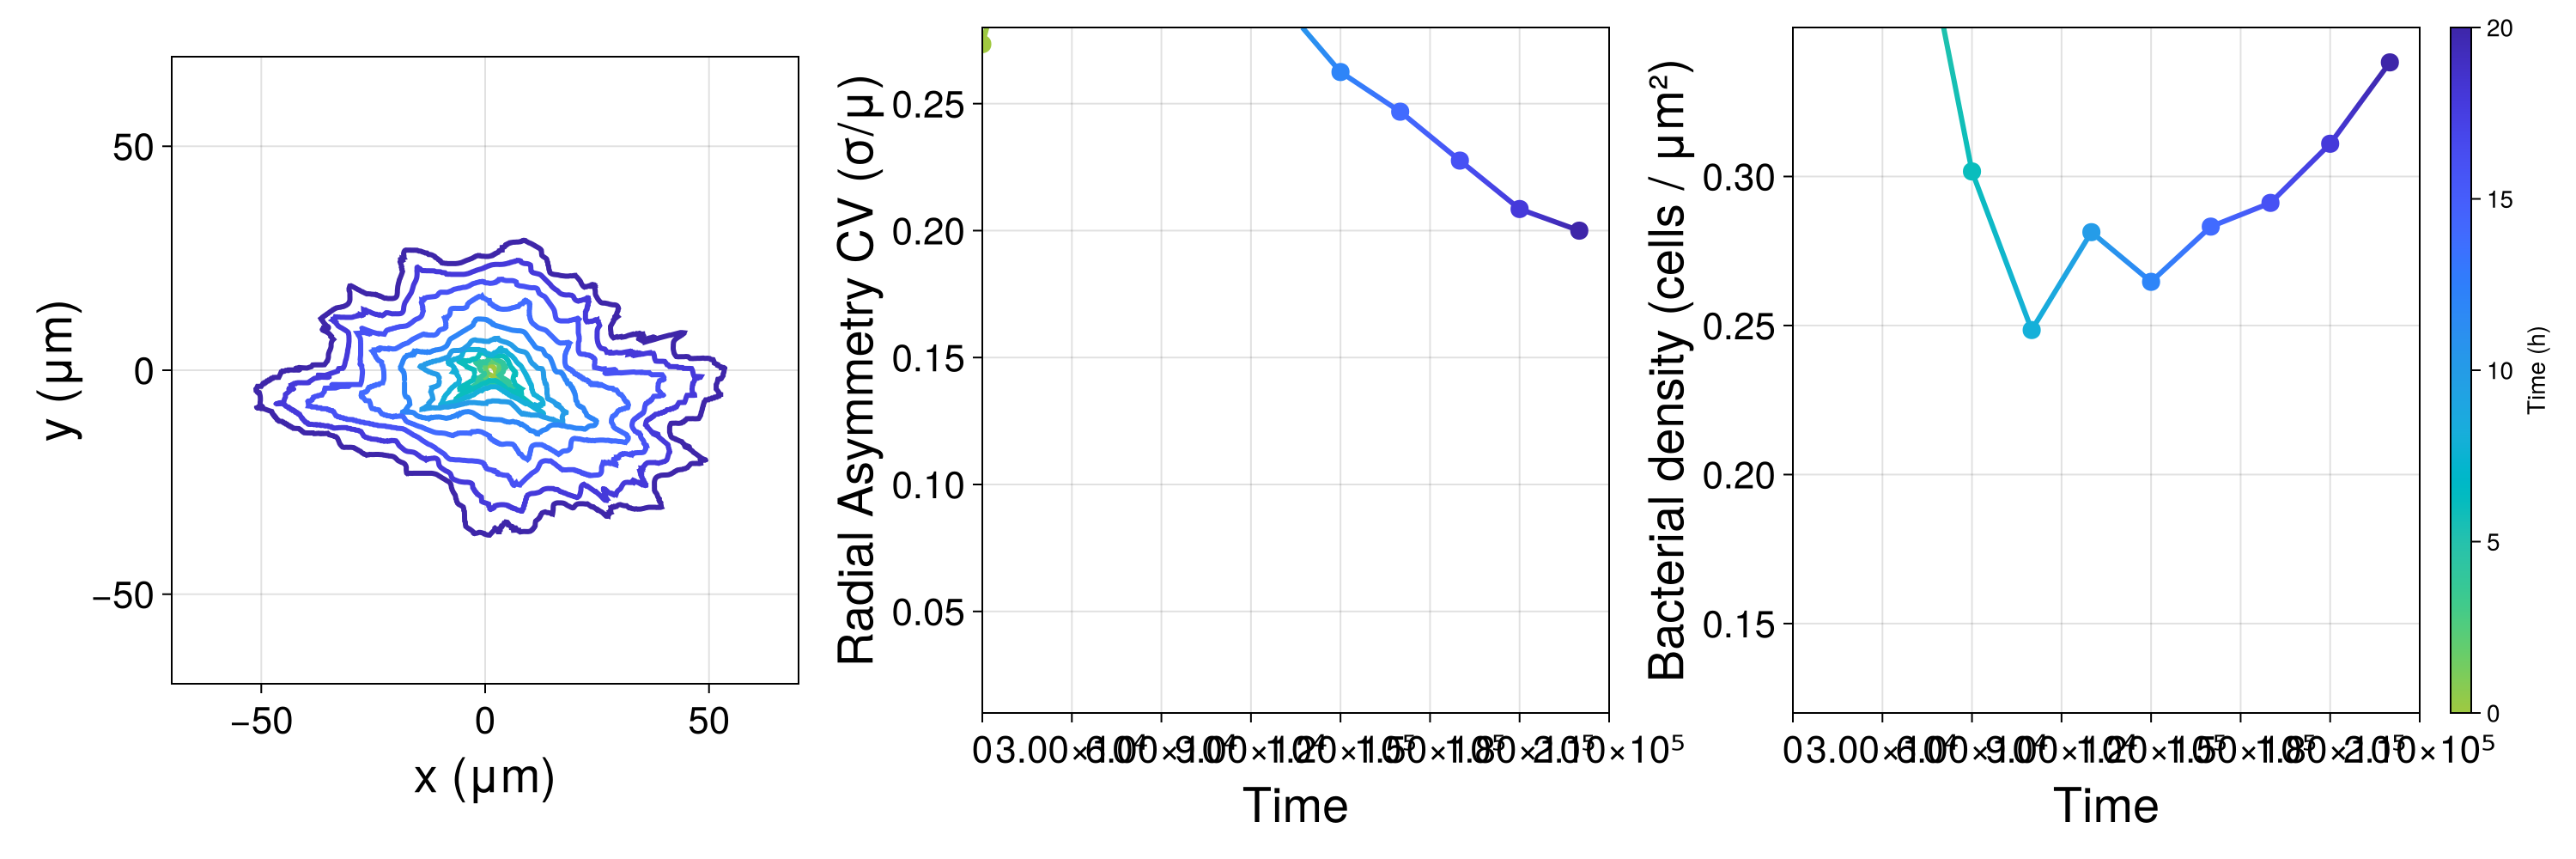

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\u256063\.julia\packages\Makie\kJl0u\src\scenes.jl:264


In [24]:
# using CairoMakie
# using Images, ImageMorphology
# using ColorSchemes
using CairoMakie: Figure, Axis, Colorbar, scatterlines!, limits!, save
using Images
using ImageMorphology

CairoMakie.activate!()

fig = Figure(resolution = (1500, 500))

file = jldopen("simulation.jld2","r")

# elegir subconjunto representativo
# js = round.(Int, range(first(steps), last(steps), length = 30))
# js=steps[50:10:end]
js=steps[1:10:end]
# js=steps[1:end]

ax1 = Axis(fig[1,1];
    xlabel = "x (μm)",
    ylabel = "y (μm)",
    aspect = DataAspect(),
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 22,
    yticklabelsize = 22
)

ax2 = Axis(fig[1,2];
    xlabel = "Time",
    ylabel = "Radial Asymmetry CV (σ/μ)",
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 22,
    yticklabelsize = 22
)

ax3 = Axis(fig[1,3];
    xlabel = "Time",
    ylabel = "Bacterial density (cells / μm²)",
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 22,
    yticklabelsize = 22
)

limits!(ax1, -70, 70, -70, 70)
limits!(ax2,  js[1]*0.9, js[end]*1.05, 0.01, 0.28)
limits!(ax3,  js[1]*0.9, js[end]*1.05, 0.12, 0.35)

cols = resample_cmap(parula, length(js))

cvs = Float64[]
densities = Float64[]

for (i, step) in enumerate(js)

    frame = file["step_$step"]

    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100,100,-100,100),
        cell_diam = 2.,
        sample_step = 0.5,
        smooth_window = 10
    )

    push!(cvs, res.cv)
    push!(densities, res.density)

    scatterlines!(ax1, res.perim_x, res.perim_y;
        color = cols[i],
        linewidth = 3,
        markersize = 3
    )
end

scatterlines!(ax2, js, cvs;
    color = cols,
    linewidth = 3,
    markersize = 15
)

scatterlines!(ax3, js, densities;
    color = cols,
    linewidth = 3,
    markersize = 15
)

Colorbar(fig[1,4];
    colormap = parula,
    limits = (js[1]/10000, js[end]/10000),
    label = "Time (h)"
)

save("NonPushing_anal.svg", fig)
display(fig)

close(file)

In [25]:
file = jldopen("simulation.jld2","r")

# obtener pasos guardados
steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
last_step = maximum(steps)

200000

In [26]:
js = steps[16:5:end-10]

16-element Vector{Int64}:
  30000
  40000
  50000
  60000
  70000
  80000
  90000
 100000
 110000
 120000
 130000
 140000
 150000
 160000
 170000
 180000

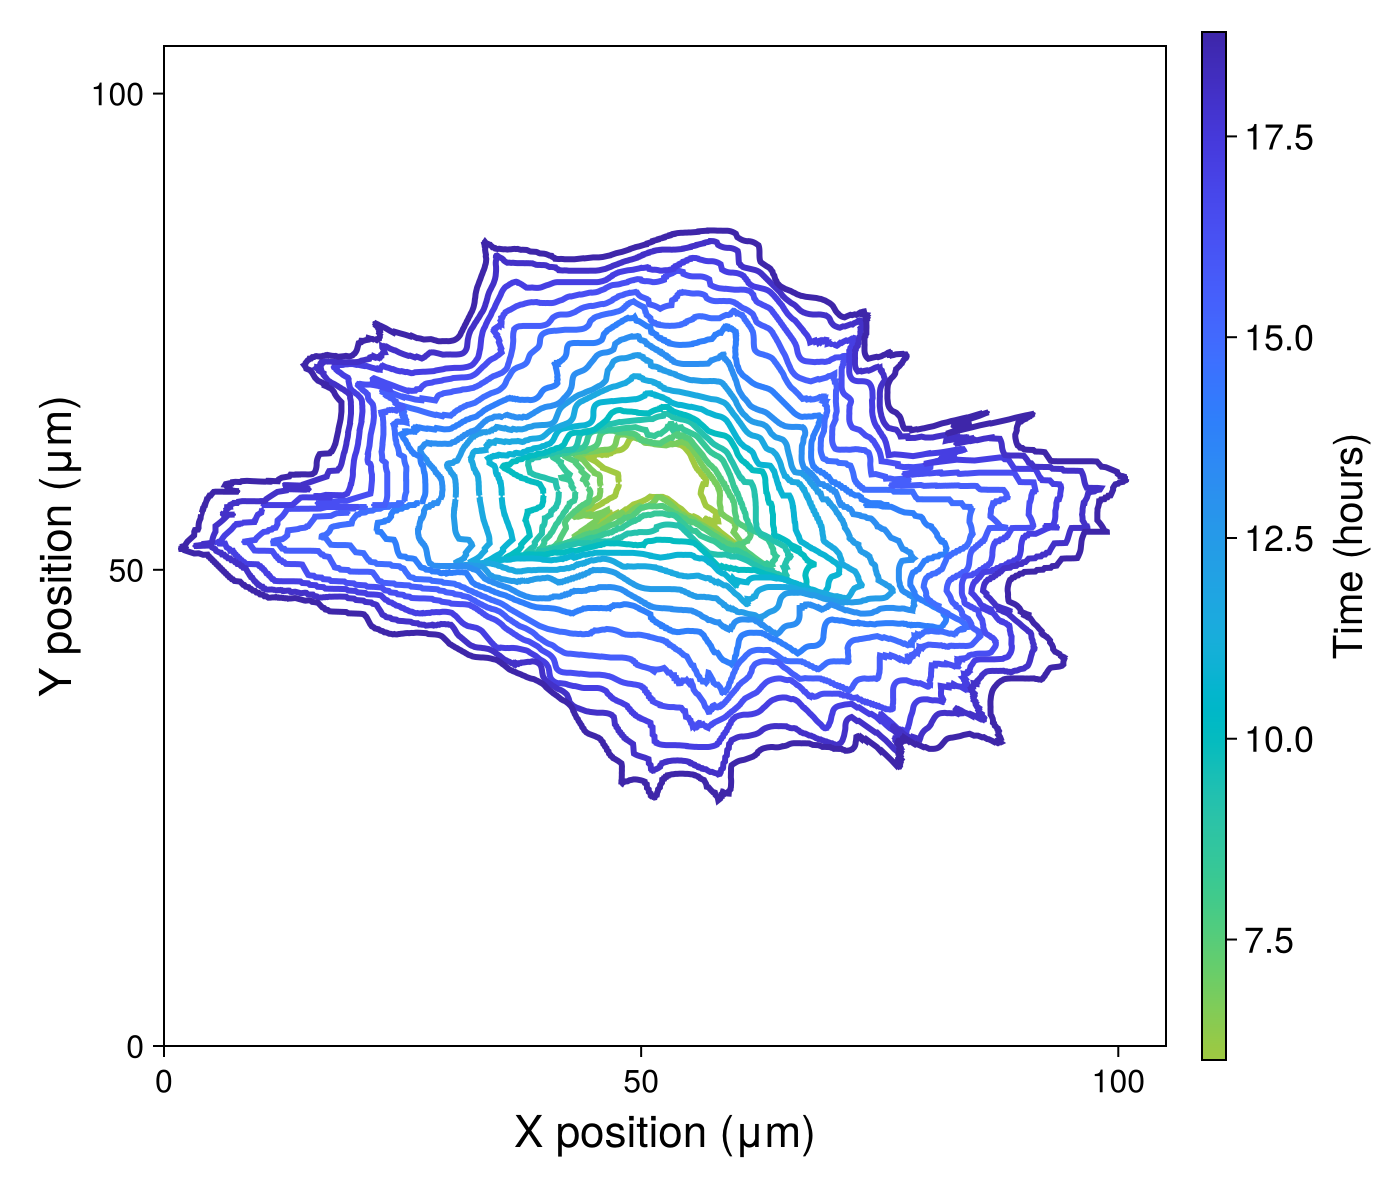

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\u256063\.julia\packages\Makie\kJl0u\src\scenes.jl:264


CairoMakie.Screen{IMAGE}


In [28]:
using CairoMakie: Figure, Axis, Colorbar, scatterlines!, limits!, save
using Images
using ImageMorphology
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2", "r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

js = steps[31:4:end-5]

cvs = Float64[]
densities = Float64[]
perims_x = Vector{Vector{Float64}}()
perims_y = Vector{Vector{Float64}}()

for step in js
    frame = file["step_$step"]

    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100, 100, -100, 100),
        cell_diam = 2.0,
        sample_step = 0.5,
        smooth_window = 10
    )

    push!(cvs, res.cv)
    push!(densities, res.density)
    push!(perims_x, res.perim_x)
    push!(perims_y, res.perim_y)
end

close(file)

cols = resample_cmap(parula, length(js))

fig1 = Figure(resolution = (700, 600))

ax1 = Axis(fig1[1, 1];
    xlabel = "X position (μm)",
    ylabel = "Y position (μm)",
    xlabelsize = 22,
    ylabelsize = 22,
    xticklabelsize = 16,
    yticklabelsize = 16,
    xgridvisible = false,
    ygridvisible = false,
    aspect = DataAspect()
)

# trasladar las curvas para que queden en coordenadas positivas,
# parecido a la figura de referencia
xshift = 50
yshift = 60

for i in eachindex(js)
    scatterlines!(ax1, perims_x[i] .+ xshift, perims_y[i] .+ yshift;
        color = cols[i],
        linewidth = 3,
        markersize = 2
    )
end

limits!(ax1, 0, 105, 0, 105)

# ax1.xticks = 20:20:60
# ax1.yticks = 20:20:60

Colorbar(fig1[1, 2];
    colormap = parula,
    limits = (js[1] / 10000, js[end] / 10000),
    label = "Time (hours)",
    labelsize = 20,
    ticklabelsize = 18
)

save("NonPushing_ax1_refstyle.svg", fig1)
display(fig1)

In [29]:
js=steps[31:4:end-5]

17-element Vector{Int64}:
  60000
  68000
  76000
  84000
  92000
 100000
 108000
 116000
 124000
 132000
 140000
 148000
 156000
 164000
 172000
 180000
 188000

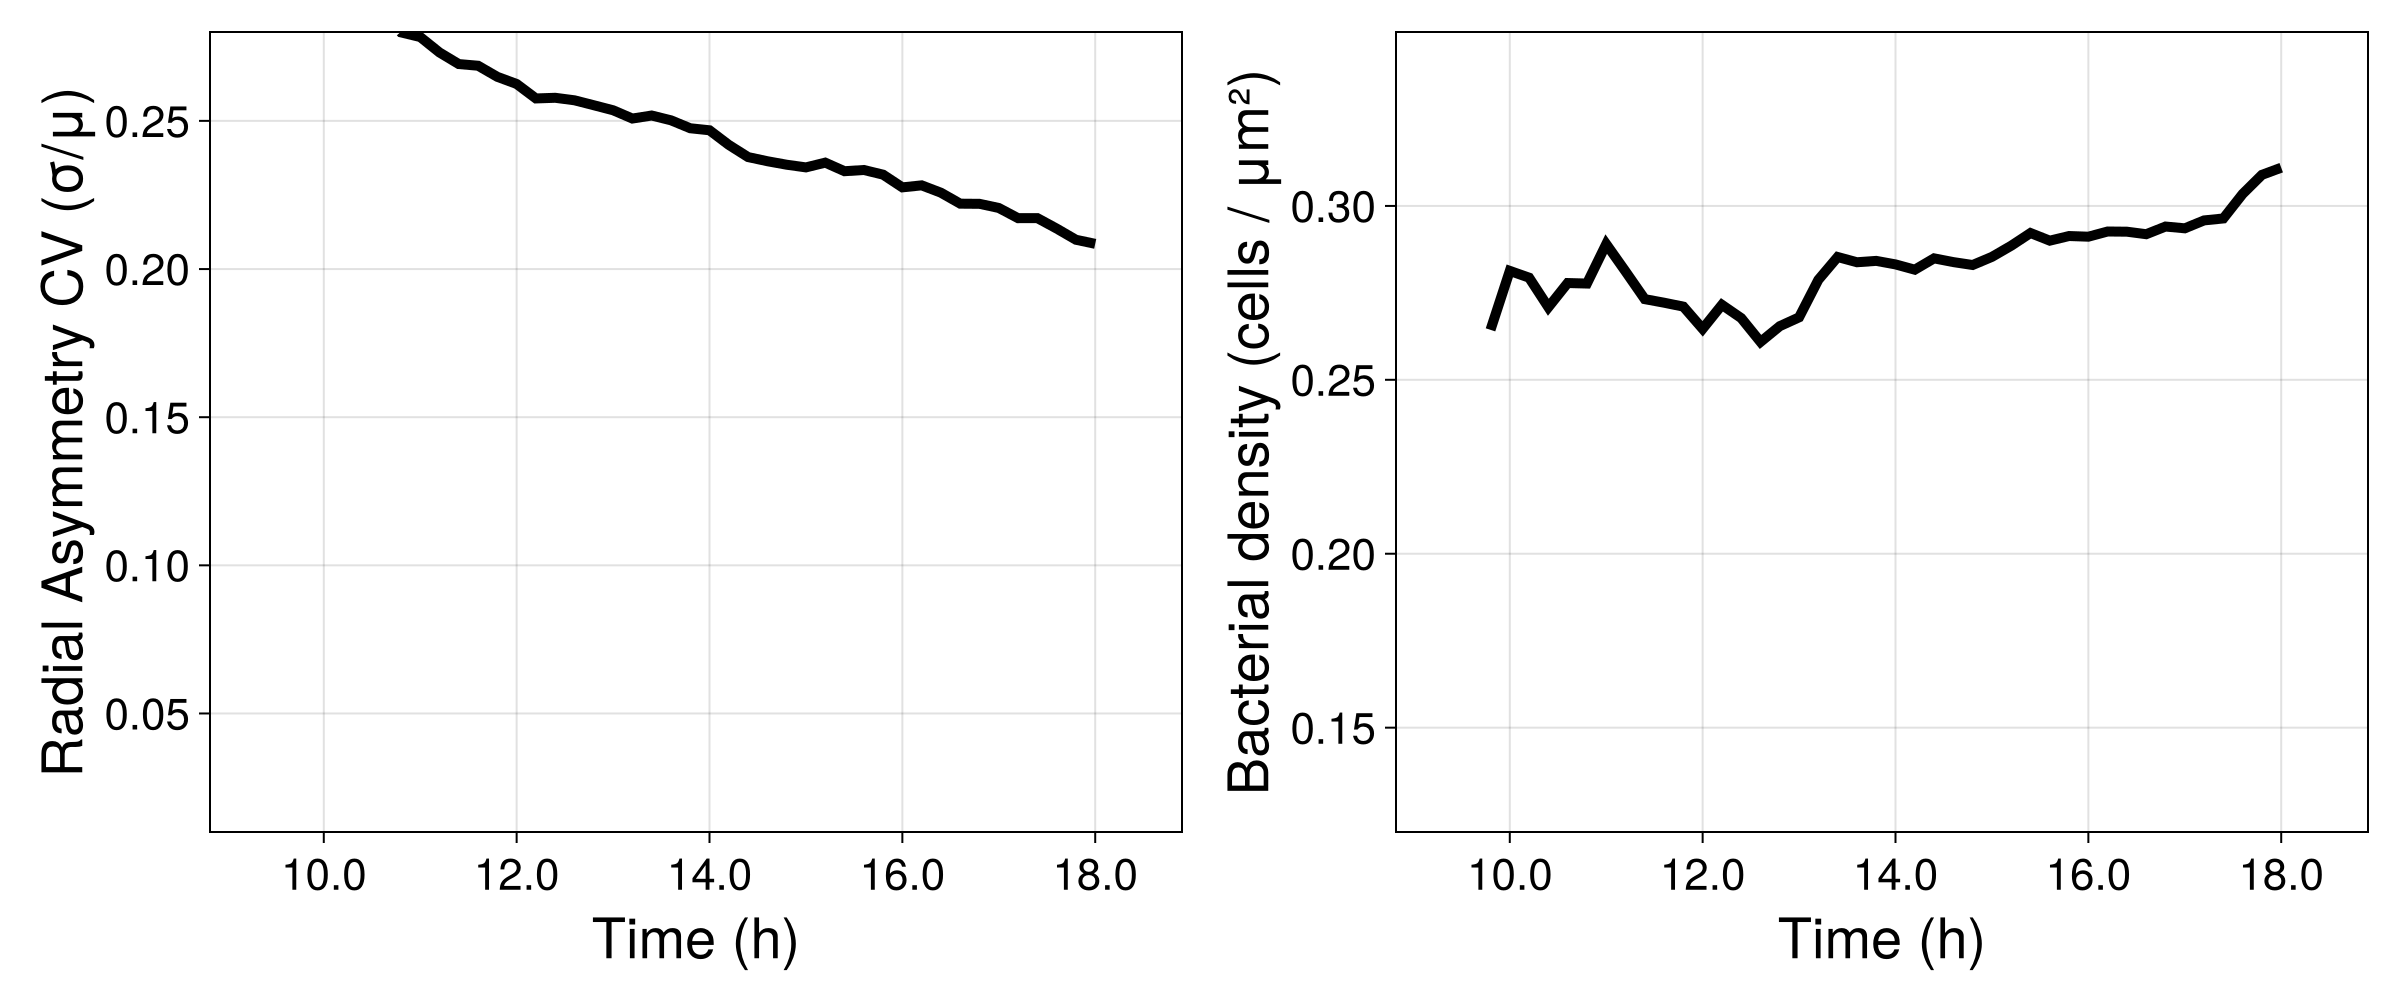

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\u256063\.julia\packages\Makie\kJl0u\src\scenes.jl:264


CairoMakie.Screen{IMAGE}


In [30]:
js = steps[50:end-10]

cvs = Float64[]
densities = Float64[]

file = jldopen("simulation.jld2", "r")

for step in js
    frame = file["step_$step"]

    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100,100,-100,100),
        cell_diam = 2.0,
        sample_step = 0.5,
        smooth_window = 10
    )

    push!(cvs, res.cv)
    push!(densities, res.density)
end

close(file)

fig2 = Figure(resolution = (1200, 500))

ax2 = Axis(fig2[1, 1];
    xlabel = "Time (h)",
    ylabel = "Radial Asymmetry CV (σ/μ)",
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 22,
    yticklabelsize = 22,
    xtickformat = values -> [string(round(v / 1e4, digits=1)) for v in values]
)

ax3 = Axis(fig2[1, 2];
    xlabel = "Time (h)",
    ylabel = "Bacterial density (cells / μm²)",
    xlabelsize = 28,
    ylabelsize = 28,
    xticklabelsize = 22,
    yticklabelsize = 22,
    xtickformat = values -> [string(round(v / 1e4, digits=1)) for v in values]
)

limits!(ax2, js[1] * 0.9, js[end] * 1.05, 0.01, 0.28)
limits!(ax3, js[1] * 0.9, js[end] * 1.05, 0.12, 0.35)

lines!(ax2, js, cvs;
    color = :black,
    linewidth = 5
)

lines!(ax3, js, densities;
    color = :black,
    linewidth = 5,
)

save("NonPushing_ax2_ax3_black.svg", fig2)
display(fig2)

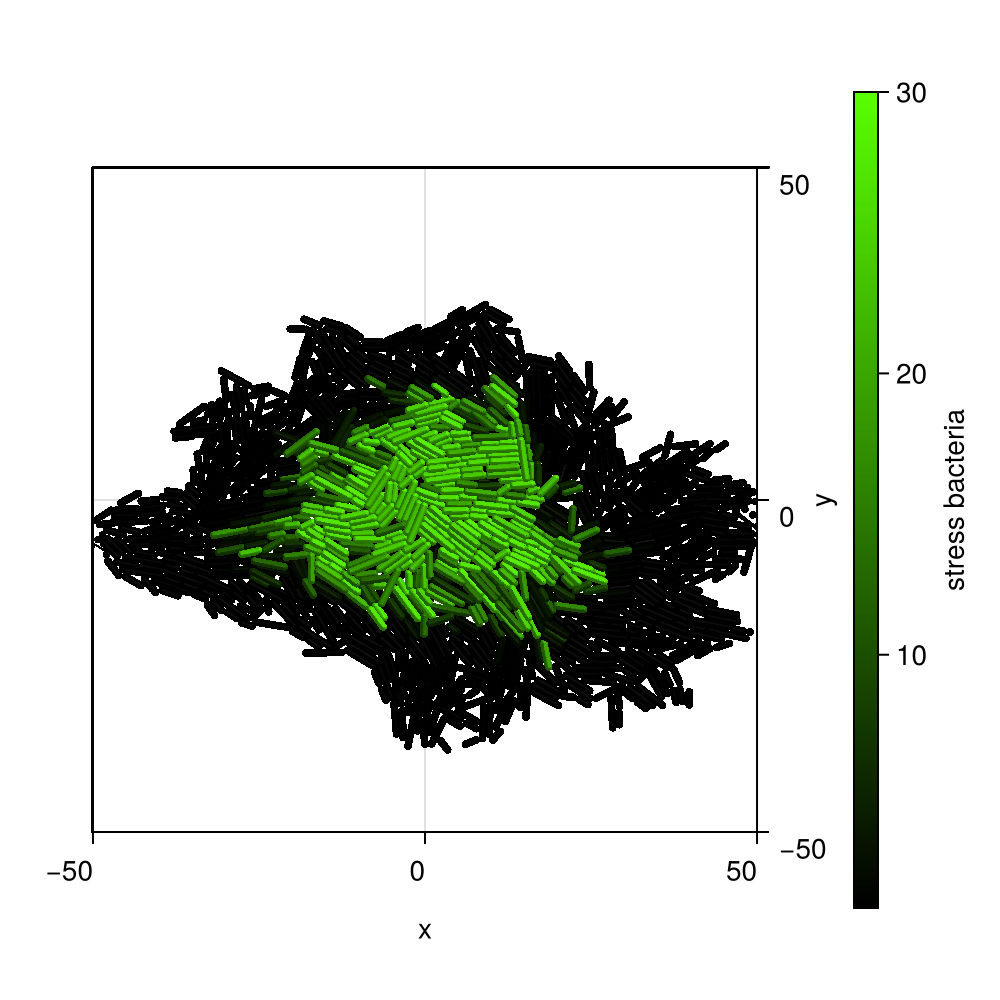

In [32]:
using CairoMakie
using JLD2

CairoMakie.activate!()

fig = Figure(size=(500,500))

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
last_step = maximum(steps)

frame = file["step_$last_step"]

# =========================
# índices en la malla HPad
# =========================

ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"],2))
iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"],1))

HP = frame["HPad"][CartesianIndex.(ix,iy)]

# campo coloreado
stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"]/2)) 

# =========================
# plot
# =========================

ax = Axis3(fig[1,1],
    azimuth = 3π/2,
    elevation = π/2,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zgridvisible=false,
    zspinesvisible=false,
    aspect = (1,1,0.5)
)

plotAgents3D_auto!(
    ax,
    frame["x"],
    frame["y"],
    -frame["z"],
    frame["d"],
    frame["l"],
    frame["theta"],
    frame["phi"],
    stress,
    colorrange = (1,30),
    colormap = cgrad([:black, "#59FF00"]),
)

xlims!(-50,50)
ylims!(-50,50)
zlims!(-10,10)

Colorbar(fig[1,2],
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,30),
    label = "stress bacteria"
)

display(fig)

close(file)

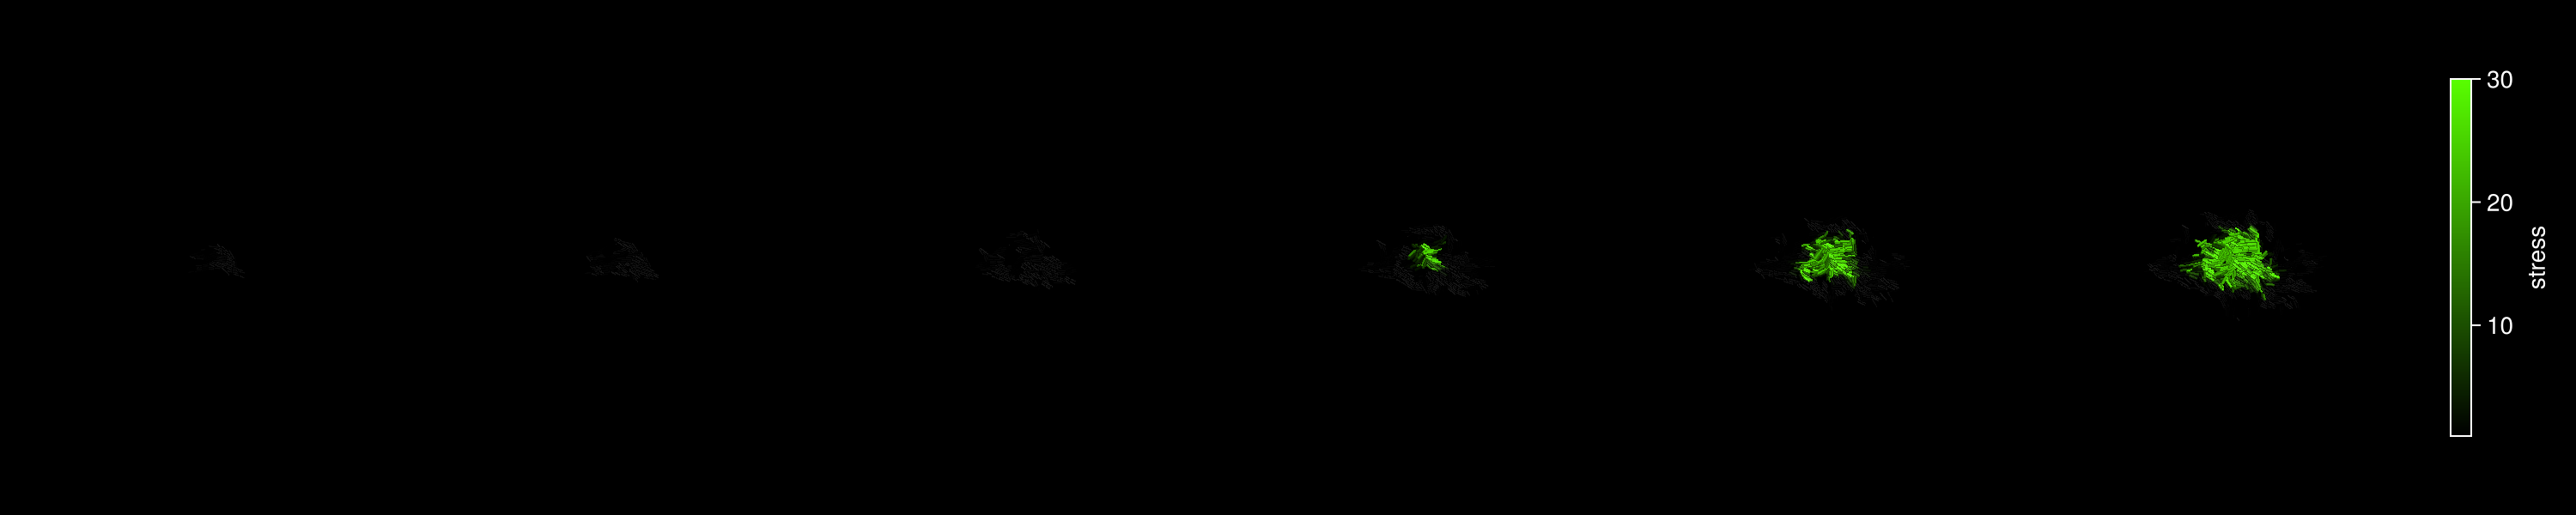

In [33]:
using CairoMakie
using JLD2

CairoMakie.activate!()

fig = Figure(
    size = (1500, 300),
    backgroundcolor = :black
)

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

idx = steps[50:10:end]

for (i, step) in enumerate(idx)

    frame = file["step_$step"]

    ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"],2))
    iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"],1))

    HP = frame["HPad"][CartesianIndex.(ix,iy)]

    stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"]/2))

    ax = Axis3(fig[1,i],
        azimuth = 3π/2,
        elevation = π/2,
        zlabelvisible = false,
        zticklabelsvisible = false,
        zgridvisible = false,
        zspinesvisible = false,
        aspect = (1,1,0.5),
        backgroundcolor = :black
    )

    plotAgents3D_auto!(
        ax,
        frame["x"],
        frame["y"],
        -frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        stress,
        colorrange = (1,30),
        colormap = cgrad([:black, "#59FF00"]),
    )

    xlims!(-80,80)
    ylims!(-80,80)
    zlims!(-10,10)
end

Colorbar(fig[1, length(idx)+1],
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,30),
    label = "stress",
    labelcolor = :white,
    ticklabelcolor = :white,
    tickcolor = :white,
    leftspinecolor = :white,
    rightspinecolor = :white,
    topspinecolor = :white,
    bottomspinecolor = :white
)

save("NonPushing_V.png", fig; dpi=1500)
display(fig)

close(file)

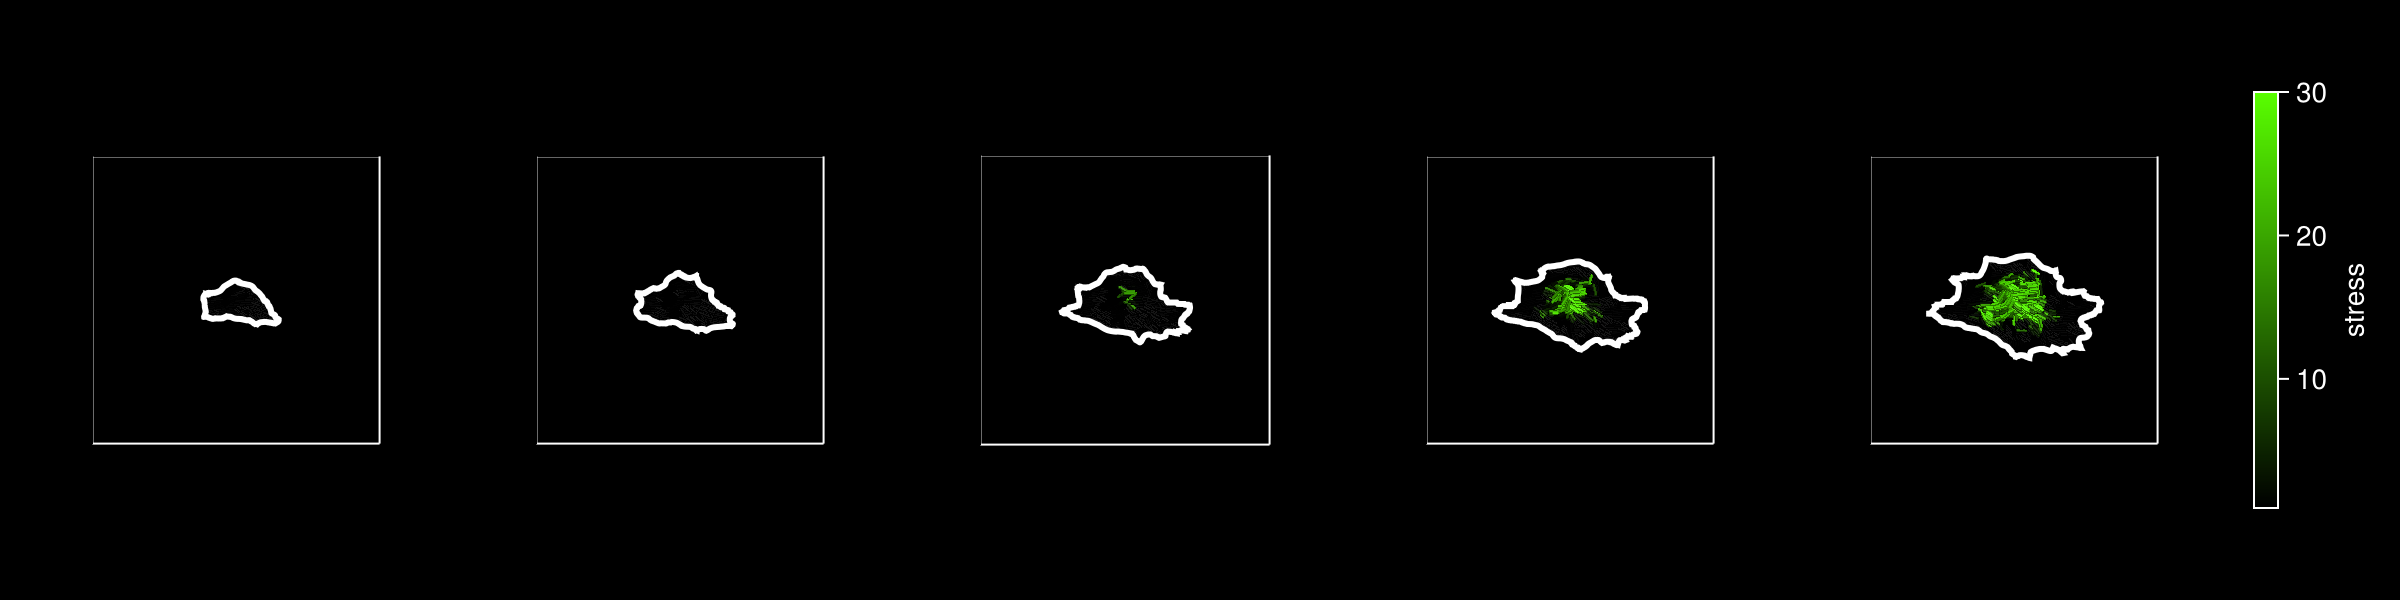

In [34]:
using CairoMakie
using JLD2

CairoMakie.activate!()

fig = Figure(
    size = (1200, 300),
    backgroundcolor = :black
)

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

idx = steps[50:20:end]
idx=steps[60:8:end-5]
for (i, step) in enumerate(idx)

    frame = file["step_$step"]

    ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"],2))
    iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"],1))

    HP = frame["HPad"][CartesianIndex.(ix,iy)]

    stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"]/2))

    ax = Axis3(fig[1,i],
        azimuth = 3π/2,
        elevation = π/2,
        zlabelvisible = false,
        zticklabelsvisible = false,
        zgridvisible = false,
        zspinesvisible = false,
        aspect = (1,1,0.5),
        backgroundcolor = :black,
        xspinecolor_1 = :white,
        yspinecolor_1 = :white,
        xspinecolor_2 = :white,
        yspinecolor_2 = :white
    )

    plotAgents3D_auto!(
        ax,
        frame["x"],
        frame["y"],
        -frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        stress,
        colorrange = (1,30),
        colormap = cgrad([:black, "#59FF00"]),
    )

    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100,100,-100,100),
        cell_diam = 2.5,
        sample_step = 0.01
    )

    scatterlines!(ax, res.perim_x, res.perim_y;
        color = :white,
        linewidth = 3,
        markersize = 3
    )

    xlims!(-80,80)
    ylims!(-80,80)
    zlims!(-10,10)
end

Colorbar(fig[1, length(idx)+1],
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,30),
    label = "stress",
    labelcolor = :white,
    ticklabelcolor = :white,
    tickcolor = :white,
    leftspinecolor = :white,
    rightspinecolor = :white,
    topspinecolor = :white,
    bottomspinecolor = :white
)

save("NonPushing_V.png", fig; dpi=1500)
display(fig)

close(file)

In [35]:
using CairoMakie
using JLD2
using Statistics

CairoMakie.activate!()

file = jldopen("simulation.jld2", "r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

step = steps[end]
frame = file["step_$step"]

# ===============================
# centroide
# ===============================
res = colony_perimeter_centroid_cv(
    frame;
    px = 0.2,
    bounds = (-100, 100, -100, 100),
    cell_diam = 2.5,
    sample_step = 0.01,
    smooth_window = 20
)

cx, cy = res.cx, res.cy

# ===============================
# stress por bacteria
# ===============================
ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"], 2))
iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"], 1))

HP = frame["HPad"][CartesianIndex.(ix, iy)]
stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"] ./ 2))

x = frame["x"] .- cx
y = frame["y"] .- cy

# ===============================
# función: perfil sobre una recta
# ===============================
function line_profile_angle(x, y, stress, θ;
    band_halfwidth = 2.5,
    nbins = 61,
    min_count_bin = 3,
    min_count_angle = 30
)

    # dirección de la recta
    ux = cos(θ)
    uy = sin(θ)

    # coordenada longitudinal y distancia perpendicular
    s = x .* ux .+ y .* uy
    p = -x .* uy .+ y .* ux

    # quedarnos con bacterias cercanas a la recta
    sel = abs.(p) .<= band_halfwidth

    if count(sel) < min_count_angle
        return nothing
    end

    s_sel = s[sel]
    stress_sel = stress[sel]

    smin = minimum(s_sel)
    smax = maximum(s_sel)

    # evitar casos degenerados
    if smax <= smin
        return nothing
    end

    # renormalizar a [-1, 1]
    snorm = 2 .* ((s_sel .- smin) ./ (smax - smin)) .- 1

    edges = range(-1, 1, length = nbins + 1)
    centers = 0.5 .* (edges[1:end-1] .+ edges[2:end])

    prof = fill(NaN, nbins)
    cnts = zeros(Int, nbins)

    for i in 1:nbins
        m = (snorm .>= edges[i]) .& (snorm .< edges[i+1])
        cnts[i] = count(m)
        if cnts[i] >= min_count_bin
            prof[i] = mean(stress_sel[m])
        end
    end

    return centers, prof, cnts
end

# ===============================
# integrar sobre ángulos
# ===============================
nangles = 80
angles = range(0, π, length = nangles)

nbins = 61
all_profiles = Matrix{Float64}(undef, nbins, 0)

for θ in angles
    out = line_profile_angle(
        x, y, stress, θ;
        band_halfwidth = 3.0,
        nbins = nbins,
        min_count_bin = 3,
        min_count_angle = 30
    )

    out === nothing && continue

    centers, prof, cnts = out

    all_profiles = hcat(all_profiles, prof)
end

# media y std ignorando NaNs
function nanmean(v)
    w = v[.!isnan.(v)]
    isempty(w) ? NaN : mean(w)
end

function nanstd(v)
    w = v[.!isnan.(v)]
    length(w) <= 1 ? NaN : std(w)
end

mean_profile = [nanmean(all_profiles[i, :]) for i in 1:size(all_profiles, 1)]
std_profile  = [nanstd(all_profiles[i, :])  for i in 1:size(all_profiles, 1)]

valid = .!isnan.(mean_profile) .& .!isnan.(std_profile)

xplot = centers[valid]
yplot = mean_profile[valid]
ylow  = yplot .- std_profile[valid]
yhigh = yplot .+ std_profile[valid]

# ===============================
# figura estilo referencia
# ===============================
fig = Figure(size = (420, 300), backgroundcolor = RGBf(0.92, 0.92, 0.92))

ax = Axis(fig[1, 1];
    xlabel = "Position",
    ylabel = "Stress (a.u.)",
    xlabelsize = 22,
    ylabelsize = 22,
    xticklabelsize = 16,
    yticklabelsize = 16,
    topspinevisible = false,
    rightspinevisible = false,
    xgridvisible = false,
    ygridvisible = false,
    backgroundcolor = RGBf(0.92, 0.92, 0.92)
)

band!(ax, xplot, ylow, yhigh;
    color = (:mediumseagreen, 0.15)
)

lines!(ax, xplot, yplot;
    color = :mediumseagreen,
    linewidth = 4
)

# text!(ax, 0, maximum(yhigh) * 0.72;
#     text = "Final time",
#     color = :dodgerblue3,
#     align = (:center, :bottom),
#     fontsize = 20,
#     font = :bold
# )

xlims!(ax, -1, 1)

save("stress_profile_angular_average.png", fig; dpi = 900)
display(fig)

close(file)

UndefVarError: UndefVarError: `centers` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

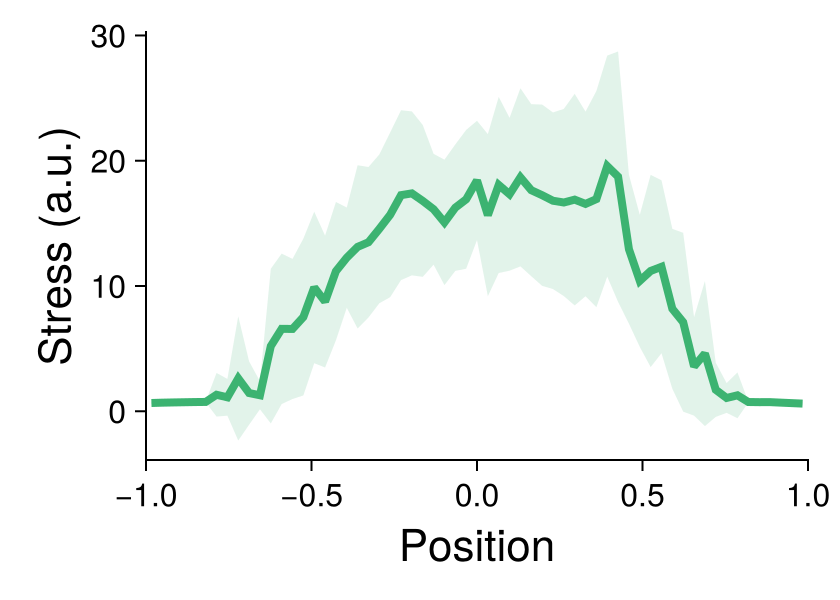

In [45]:

using CairoMakie
using JLD2
using Statistics

CairoMakie.activate!()

file = jldopen("simulation.jld2", "r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

step = steps[end]
frame = file["step_$step"]

# ===============================
# centroide
# ===============================
res = colony_perimeter_centroid_cv(
    frame;
    px = 0.2,
    bounds = (-100, 100, -100, 100),
    cell_diam = 2.5,
    sample_step = 0.01,
    smooth_window = 20
)

cx, cy = res.cx, res.cy

# ===============================
# stress por bacteria
# ===============================
ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"], 2))
iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"], 1))

HP = frame["HPad"][CartesianIndex.(ix, iy)]
stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"] ./ 2))

x = frame["x"] .- cx
y = frame["y"] .- cy

# ===============================
# función: perfil sobre una recta
# ===============================
function line_profile_angle(x, y, stress, θ;
    band_halfwidth = 2.5,
    nbins = 61,
    min_count_bin = 3,
    min_count_angle = 30
)

    ux = cos(θ)
    uy = sin(θ)

    s = x .* ux .+ y .* uy
    p = -x .* uy .+ y .* ux

    sel = abs.(p) .<= band_halfwidth

    if count(sel) < min_count_angle
        return nothing
    end

    s_sel = s[sel]
    stress_sel = stress[sel]

    smin = minimum(s_sel)
    smax = maximum(s_sel)

    if smax <= smin
        return nothing
    end

    snorm = 2 .* ((s_sel .- smin) ./ (smax - smin)) .- 1

    edges = range(-1, 1, length = nbins + 1)
    centers_local = 0.5 .* (edges[1:end-1] .+ edges[2:end])

    prof = fill(NaN, nbins)
    cnts = zeros(Int, nbins)

    for i in 1:nbins
        m = (snorm .>= edges[i]) .& (snorm .< edges[i+1])
        cnts[i] = count(m)
        if cnts[i] >= min_count_bin
            prof[i] = mean(stress_sel[m])
        end
    end

    return centers_local, prof, cnts
end

# ===============================
# integrar sobre ángulos
# ===============================
nangles = 80
angles = range(0, π, length = nangles)

nbins = 61
edges = range(-1, 1, length = nbins + 1)
centers = 0.5 .* (edges[1:end-1] .+ edges[2:end])

all_profiles = Matrix{Float64}(undef, nbins, 0)

for θ in angles
    out = line_profile_angle(
        x, y, stress, θ;
        band_halfwidth = 3.0,
        nbins = nbins,
        min_count_bin = 3,
        min_count_angle = 30
    )

    out === nothing && continue

    _, prof, cnts = out
    all_profiles = hcat(all_profiles, prof)
end

# por si ningún ángulo fue válido
@assert size(all_profiles, 2) > 0 "No se obtuvo ningún perfil válido. Prueba aumentando band_halfwidth o reduciendo min_count_angle."

# ===============================
# media y std ignorando NaNs
# ===============================
function nanmean(v)
    w = v[.!isnan.(v)]
    isempty(w) ? NaN : mean(w)
end

function nanstd(v)
    w = v[.!isnan.(v)]
    length(w) <= 1 ? NaN : std(w)
end

mean_profile = [nanmean(all_profiles[i, :]) for i in 1:size(all_profiles, 1)]
std_profile  = [nanstd(all_profiles[i, :])  for i in 1:size(all_profiles, 1)]

valid = .!isnan.(mean_profile) .& .!isnan.(std_profile)

xplot = centers[valid]
yplot = mean_profile[valid]
ylow  = yplot .- std_profile[valid]
yhigh = yplot .+ std_profile[valid]

# ===============================
# figura
# ===============================
fig = Figure(size = (420, 300))

ax = Axis(fig[1, 1];
    xlabel = "Position",
    ylabel = "Stress (a.u.)",
    xlabelsize = 22,
    ylabelsize = 22,
    xticklabelsize = 16,
    yticklabelsize = 16,
    topspinevisible = false,
    rightspinevisible = false,
    xgridvisible = false,
    ygridvisible = false,
    # backgroundcolor = RGBf(0.92, 0.92, 0.92)
)

band!(ax, xplot, ylow, yhigh;
    color = (:mediumseagreen, 0.15)
)

lines!(ax, xplot, yplot;
    color = :mediumseagreen,
    linewidth = 4
)

xlims!(ax, -1, 1)

save("stress_profile_angular_average.png", fig; dpi = 900)
display(fig)

close(file)

In [41]:
using CairoMakie
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

# =========================
# figura
# =========================

fig = Figure(size = (800,600))
grid = fig[1,1] = GridLayout()

ax1 = Axis3(grid[1,1];
    azimuth = 3π/2,
    elevation = π/2,
    zlabelvisible = false,
    zticklabelsvisible = false,
    zgridvisible = false,
    zspinesvisible = false,
    aspect = (1,1,0.1)
)

ax1.xgridvisible = true
ax1.ygridvisible = true

Colorbar(fig[1,2];
    colormap = :viridis,
    colorrange = (0,3),
    label = "z bacteria"
)

# =========================
# animación
# =========================

Makie.record(fig, "Colony_z.mp4", 1:2:length(steps); framerate = 10) do i

    step = steps[i]
    frame = file["step_$step"]

    Makie.empty!(ax1)

    plotAgents3D_auto!(
        ax1,
        frame["x"],
        frame["y"],
        frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        frame["z"],
        colorrange = (0,3),
        colormap = :viridis
    )

    xlims!(ax1, -100,100)
    ylims!(ax1, -100,100)
    zlims!(ax1, -2,8)

end

close(file)

In [37]:
using CairoMakie
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

# =========================
# figura
# =========================

fig = Figure(size = (800,600))
grid = fig[1,1] = GridLayout()

ax1 = Axis3(grid[1,1];
    azimuth = 3π/2,
    elevation = π/2,
    zlabelvisible = false,
    zticklabelsvisible = false,
    zgridvisible = false,
    zspinesvisible = false,
    aspect = (1,1,0.1)
)

ax1.xgridvisible = true
ax1.ygridvisible = true

Colorbar(fig[1,2];
    colormap = Reverse(:grays),
    colorrange = (-1,2.5),
    label = "z bacteria"
)

# =========================
# animación
# =========================

Makie.record(fig, "Colony_z_g.mp4", 1:2:length(steps); framerate = 10) do i

    step = steps[i]
    frame = file["step_$step"]

    Makie.empty!(ax1)

    plotAgents3D_auto!(
        ax1,
        frame["x"],
        frame["y"],
        frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        frame["z"],
        colorrange = (-1,2.5),
        colormap = Reverse(:grays),
    )

    xlims!(ax1, -100,100)
    ylims!(ax1, -100,100)
    zlims!(ax1, -2,8)

end

close(file)

In [38]:
using CairoMakie
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

# =========================
# figura
# =========================

fig = Figure(size = (800,600))

ax1 = Axis3(fig[1,1];
    azimuth = 3π/2,
    elevation = -π/2,
    zlabelvisible = false,
    zticklabelsvisible = false,
    zgridvisible = false,
    zspinesvisible = false,
    aspect = (1,1,0.1)
)

ax1.xgridvisible = true
ax1.ygridvisible = true

Colorbar(fig[1,2];
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,3),
    label = "Stress"
)

# =========================
# animación
# =========================

Makie.record(fig, "Colony_V.mp4", 1:2:length(steps); framerate = 10) do i

    step = steps[i]
    frame = file["step_$step"]

    Makie.empty!(ax1)

    plotAgents3D_auto!(
        ax1,
        frame["x"],
        frame["y"],
        frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        frame["V"],
        colormap = cgrad([:black, "#59FF00"]),
        colorrange = (1,3),
    )

    xlims!(ax1, -100,100)
    ylims!(ax1, 100,-100)
    zlims!(ax1, -2,8)

end

close(file)

In [39]:
using CairoMakie
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

# =========================
# figura
# =========================

fig = Figure(size = (800,600),
    backgroundcolor = :black
)

ax1 = Axis3(fig[1,1];
    azimuth = 3π/2,
    elevation = -π/2,
    zlabelvisible = false,
    zticklabelsvisible = false,
    zgridvisible = false,
    zspinesvisible = false,
    aspect = (1,1,0.1)
)

ax1.xgridvisible = true
ax1.ygridvisible = true

Colorbar(fig[1,2];
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,30),
    label = "Stress",
    labelcolor = :white,
    ticklabelcolor = :white,
    tickcolor = :white,
    leftspinecolor = :white,
    rightspinecolor = :white,
    topspinecolor = :white,
    bottomspinecolor = :white
)



# =========================
# animación
# =========================

# Makie.record(fig, "Colony_s.mp4", 1:2:10; framerate = 10) do i
Makie.record(fig, "Colony_s.mp4", 1:2:length(steps); framerate = 10) do i

    step = steps[i]
    frame = file["step_$step"]

    ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"],2))
    iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"],1))

    HP = frame["HPad"][CartesianIndex.(ix,iy)]

    # campo coloreado
    stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"]/2)) 

    Makie.empty!(ax1)

    plotAgents3D_auto!(
        ax1,
        frame["x"],
        frame["y"],
        frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        stress,
        colormap = cgrad([:black, "#59FF00"]),
        colorrange = (1,30),
    )
    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100,100,-100,100),
        cell_diam = 2.,
        sample_step = 0.5,
        smooth_window = 10
    )

    scatterlines!(ax1, res.perim_x, res.perim_y;
        color = :white,
        linewidth = 1,
        markersize = 3
    )

    xlims!(ax1, -100,100)
    ylims!(ax1, 100,-100)
    zlims!(ax1, -2,8)

end

close(file)

In [40]:
using CairoMakie
using JLD2

CairoMakie.activate!()

file = jldopen("simulation.jld2","r")

steps = parse.(Int, replace.(collect(keys(file)), "step_" => ""))
sort!(steps)

# =========================
# figura
# =========================

fig = Figure(
    size = (800,600),
    backgroundcolor = :black
)

title_lbl = Label(fig[0,1],
    "t = 0h",
    color = :white,
    fontsize = 24,
    tellwidth = false
)

ax1 = Axis3(fig[1,1];
    azimuth = 3π/2,
    elevation = -π/2,
    zlabelvisible = false,
    zticklabelsvisible = false,
    zgridvisible = false,
    zspinesvisible = false,
    aspect = (1,1,0.1),
    backgroundcolor = :black,
    # xspinecolor_1 = :white,
    # yspinecolor_1 = :white,
    # xspinecolor_2 = :white,
    # yspinecolor_2 = :white
)

ax1.xgridvisible = true
ax1.ygridvisible = true

Colorbar(fig[1,2];
    colormap = cgrad([:black, "#59FF00"]),
    colorrange = (1,30),
    label = "Stress",
    labelcolor = :white,
    ticklabelcolor = :white,
    tickcolor = :white,
    leftspinecolor = :white,
    rightspinecolor = :white,
    topspinecolor = :white,
    bottomspinecolor = :white
)

# =========================
# animación
# =========================

Makie.record(fig, "Colony_s.mp4", 1:2:length(steps); framerate = 10) do i

    step = steps[i]
    frame = file["step_$step"]

    title_lbl.text = "t = $(step/10000)h"

    ix = clamp.(round.(Int, frame["x"] .+ 100) .+ 1, 1, size(frame["HPad"],2))
    iy = clamp.(round.(Int, frame["y"] .+ 100) .+ 1, 1, size(frame["HPad"],1))

    HP = frame["HPad"][CartesianIndex.(ix,iy)]

    stress = exp.(frame["gamma_c"] .* (HP .- frame["z"] .- frame["d"]/2))

    Makie.empty!(ax1)

    plotAgents3D_auto!(
        ax1,
        frame["x"],
        frame["y"],
        frame["z"],
        frame["d"],
        frame["l"],
        frame["theta"],
        frame["phi"],
        stress,
        colormap = cgrad([:black, "#59FF00"]),
        colorrange = (1,30),
    )

    res = colony_perimeter_centroid_cv(
        frame;
        px = 0.2,
        bounds = (-100,100,-100,100),
        cell_diam = 2.,
        sample_step = 0.5,
        smooth_window = 10
    )

    scatterlines!(ax1, res.perim_x, res.perim_y, zeros(length(res.perim_x));
        color = :white,
        linewidth = 1,
        markersize = 3
    )

    xlims!(ax1, -100,100)
    ylims!(ax1, 100,-100)
    zlims!(ax1, -2,8)

end

close(file)